ResNet → Cars
ResNet → Cats
ResNet → Dogs
ResNet → Rangoli
VGG → Cars
VGG → Cats
VGG → Dogs
VGG → Rangoli
Inception3 → Cars
Inception3 → Cats
Inception3 → Dogs
Inception3 → Rangoli
MobileNetV2 → Cars
MobileNetV2 → Cats
MobileNetV2 → Dogs
MobileNetV2 → Rangoli


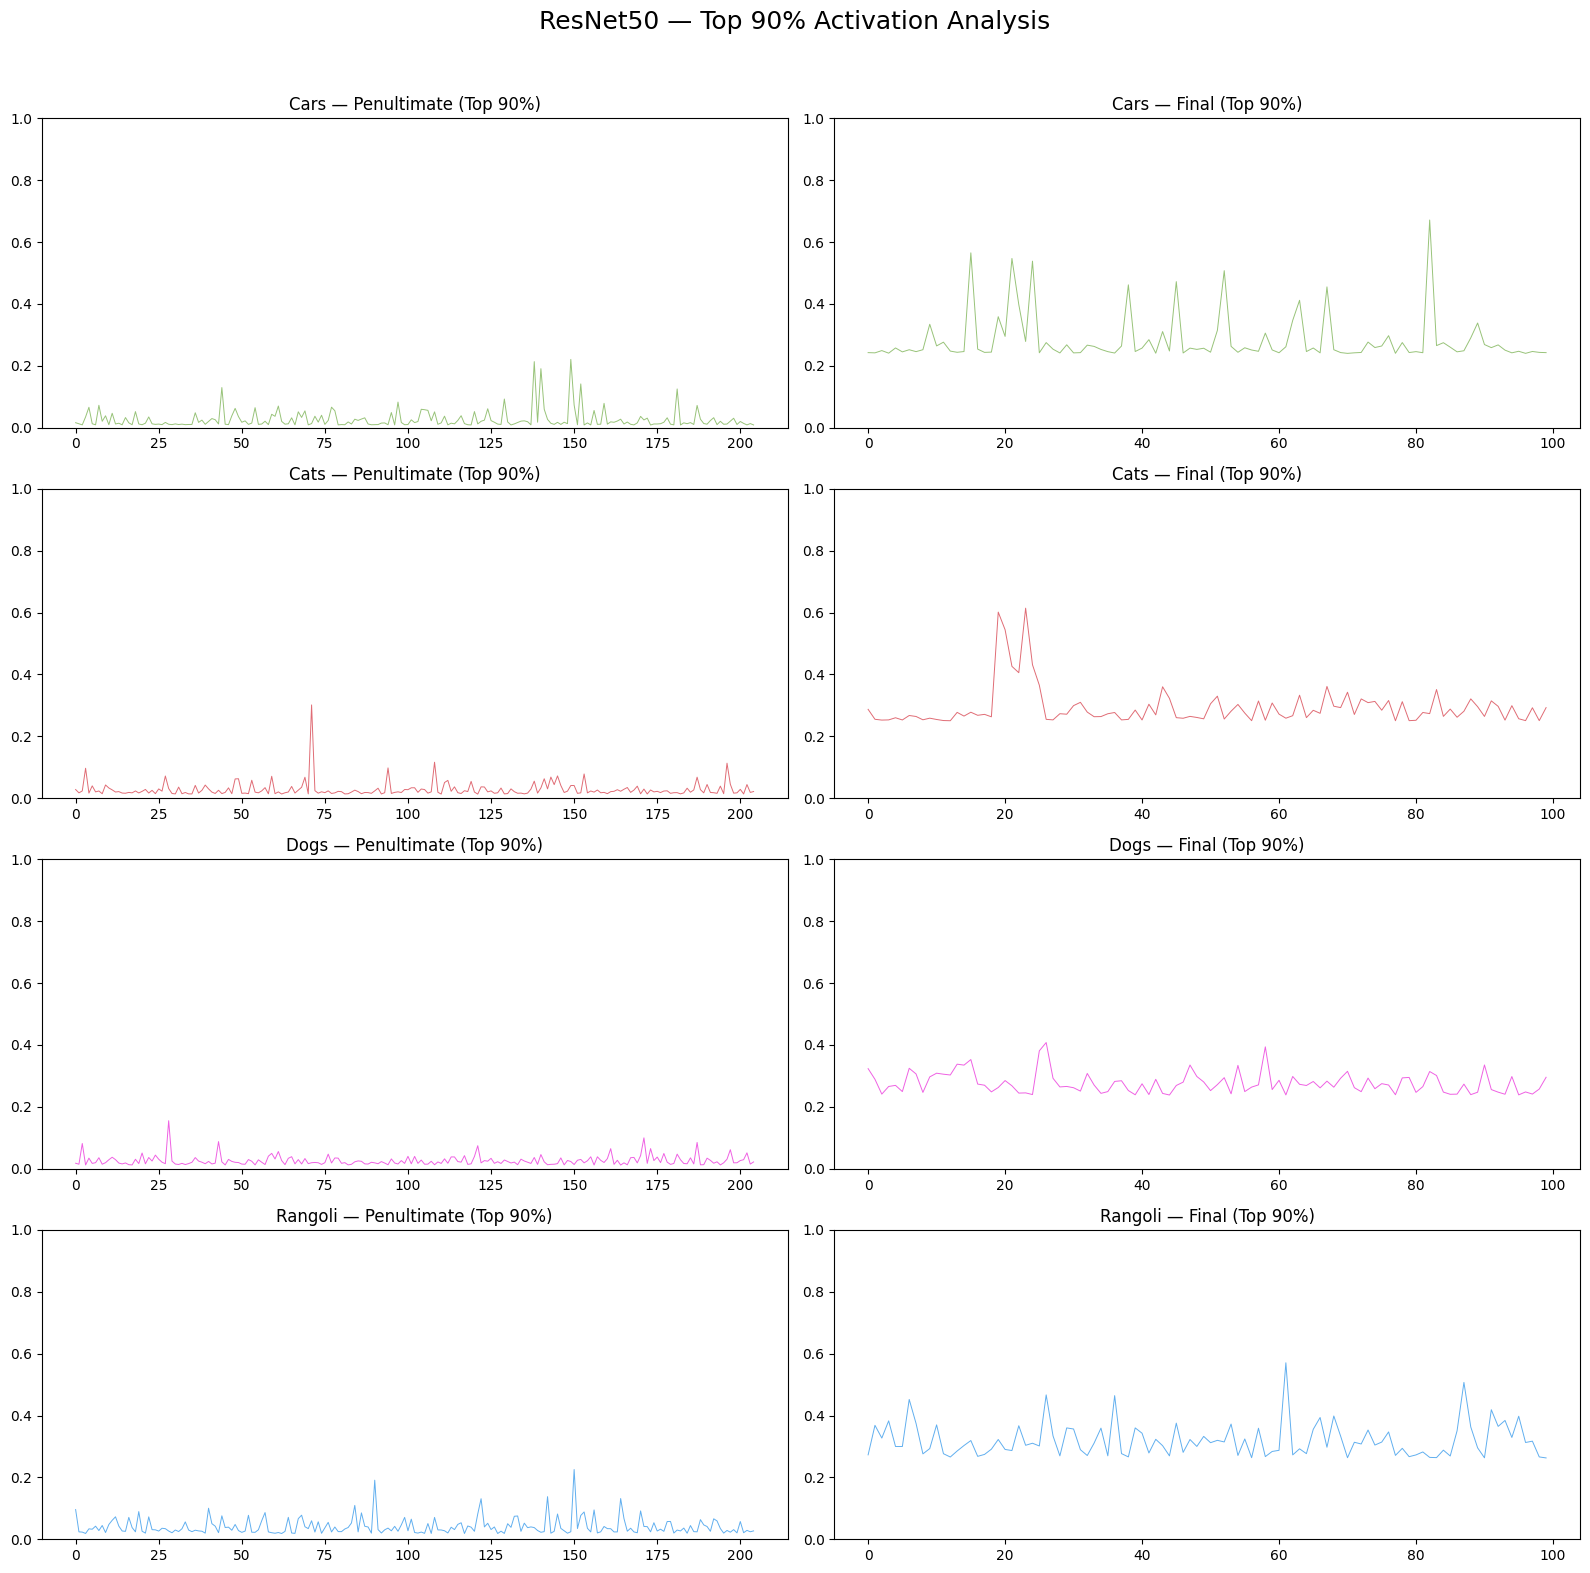

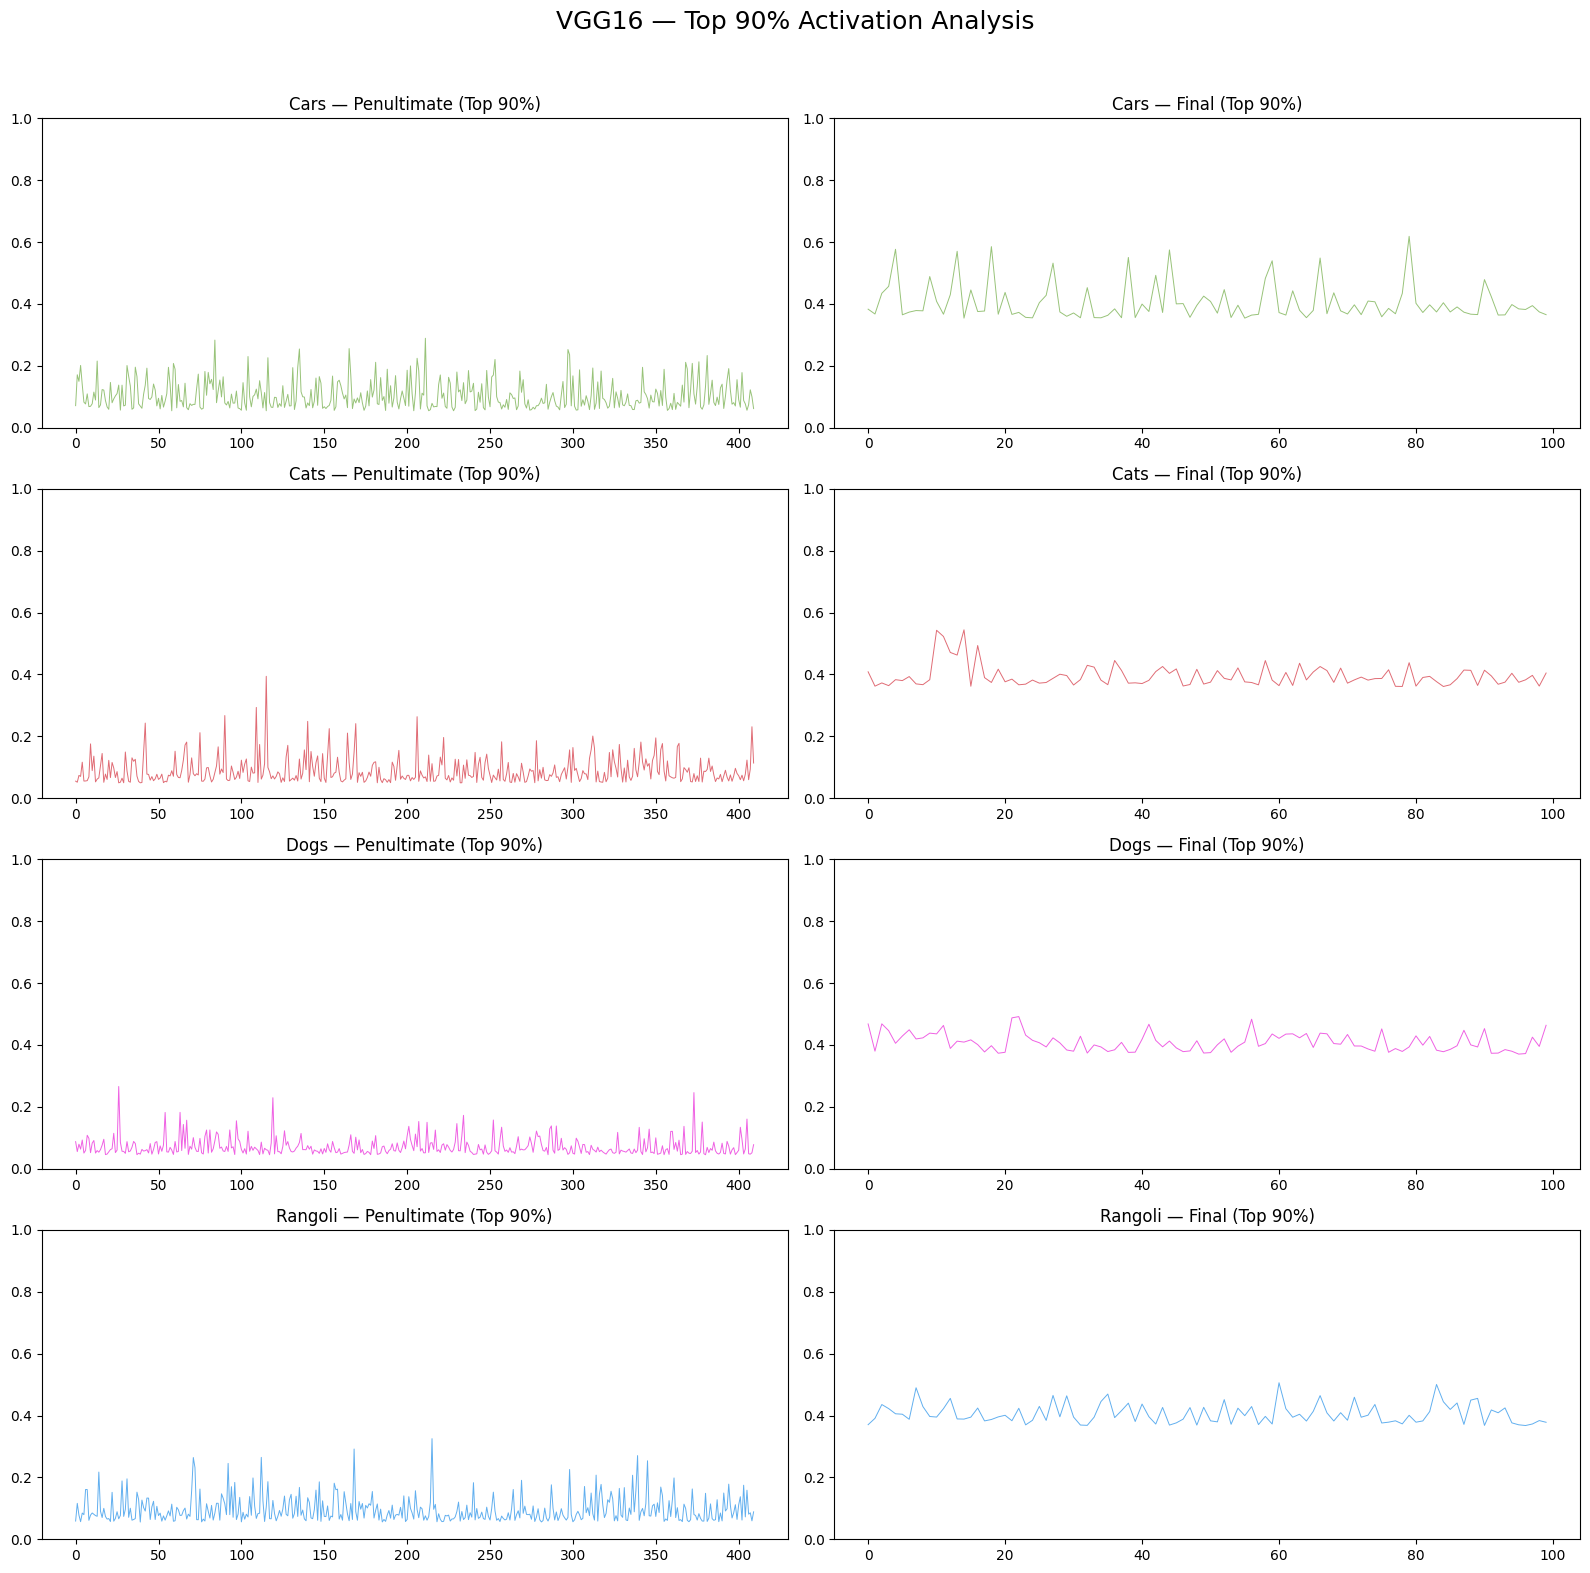

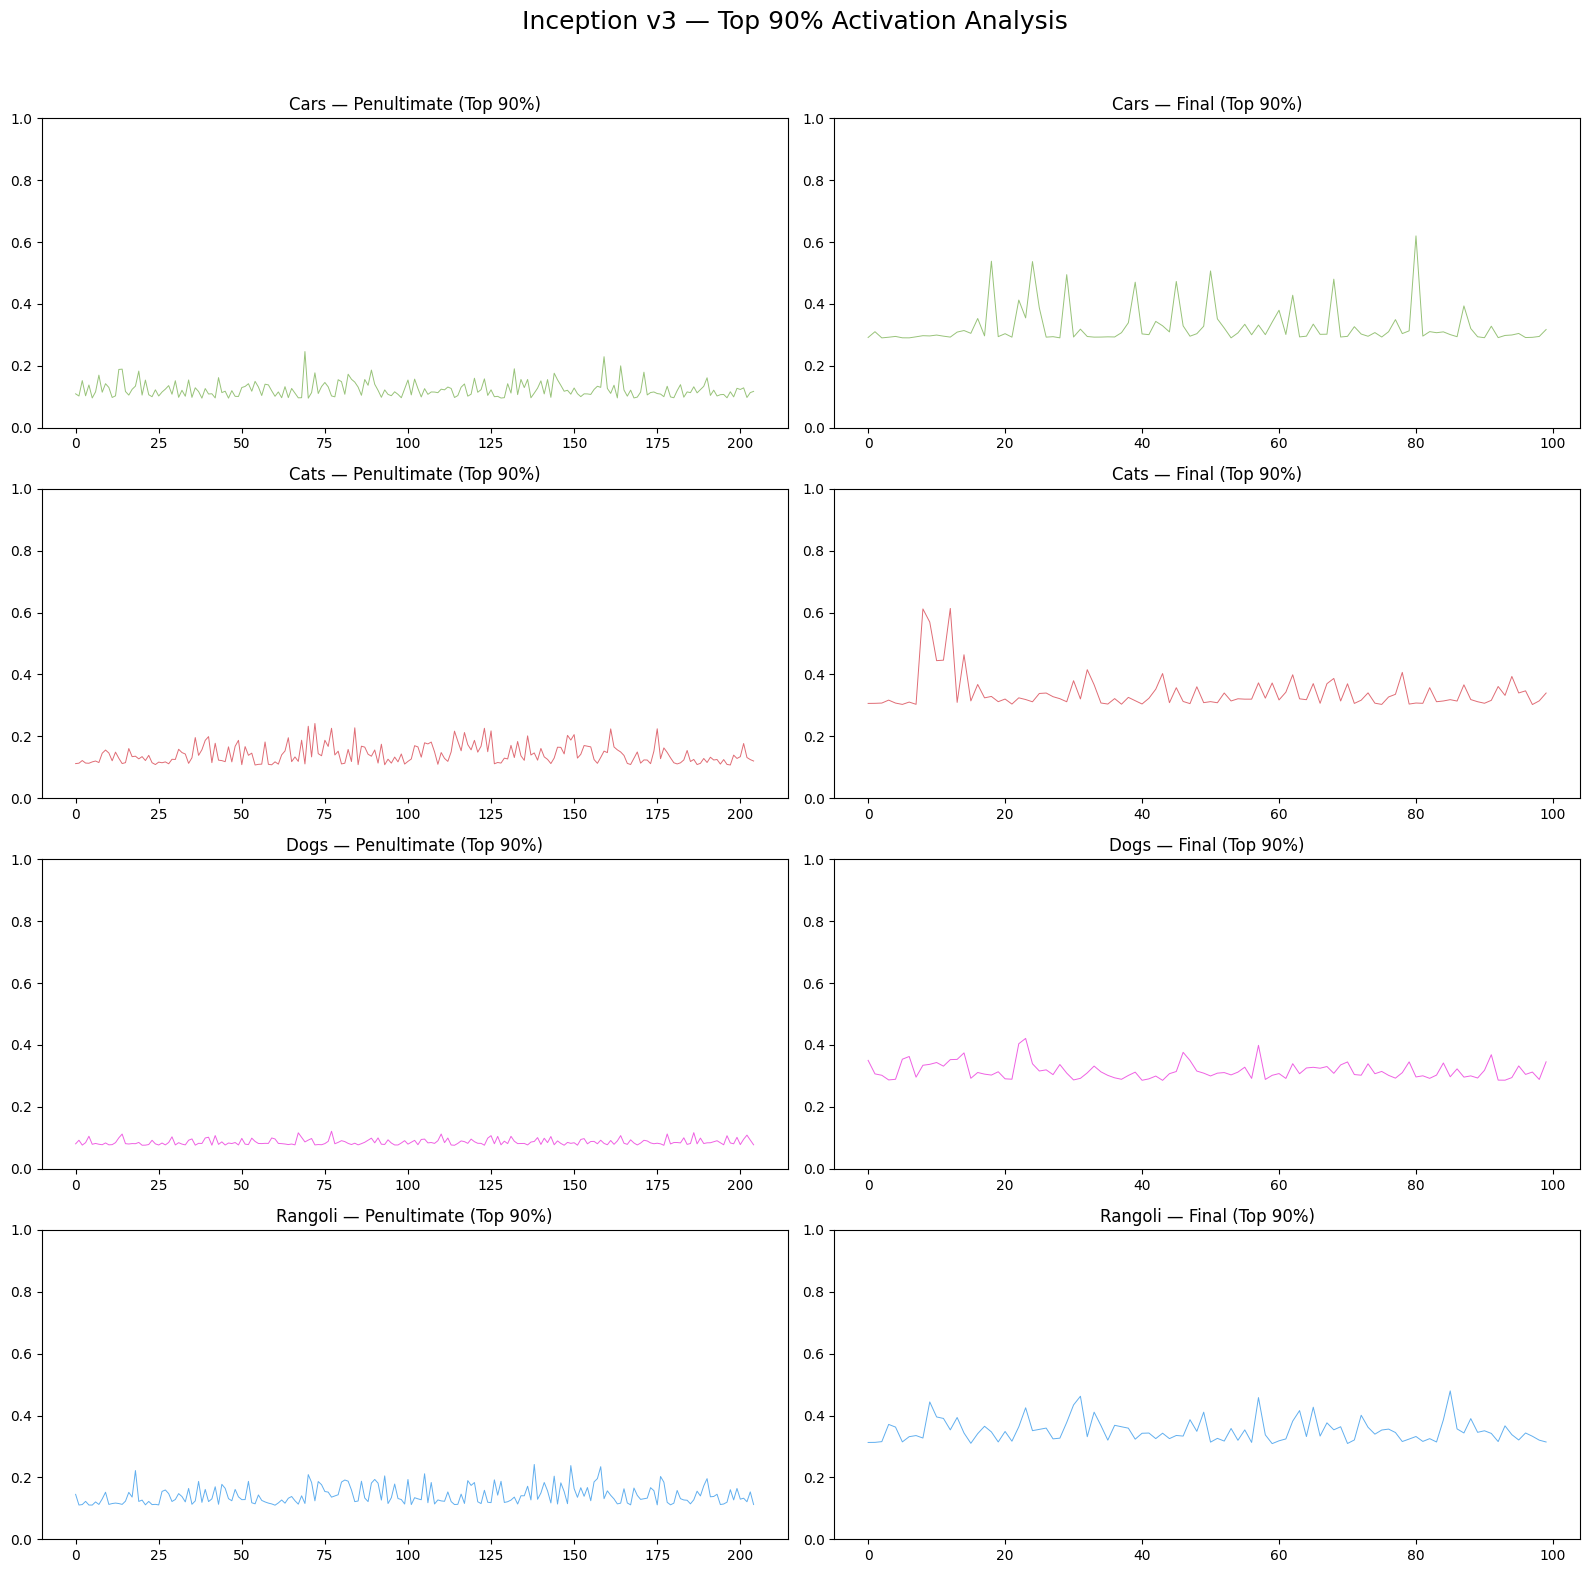

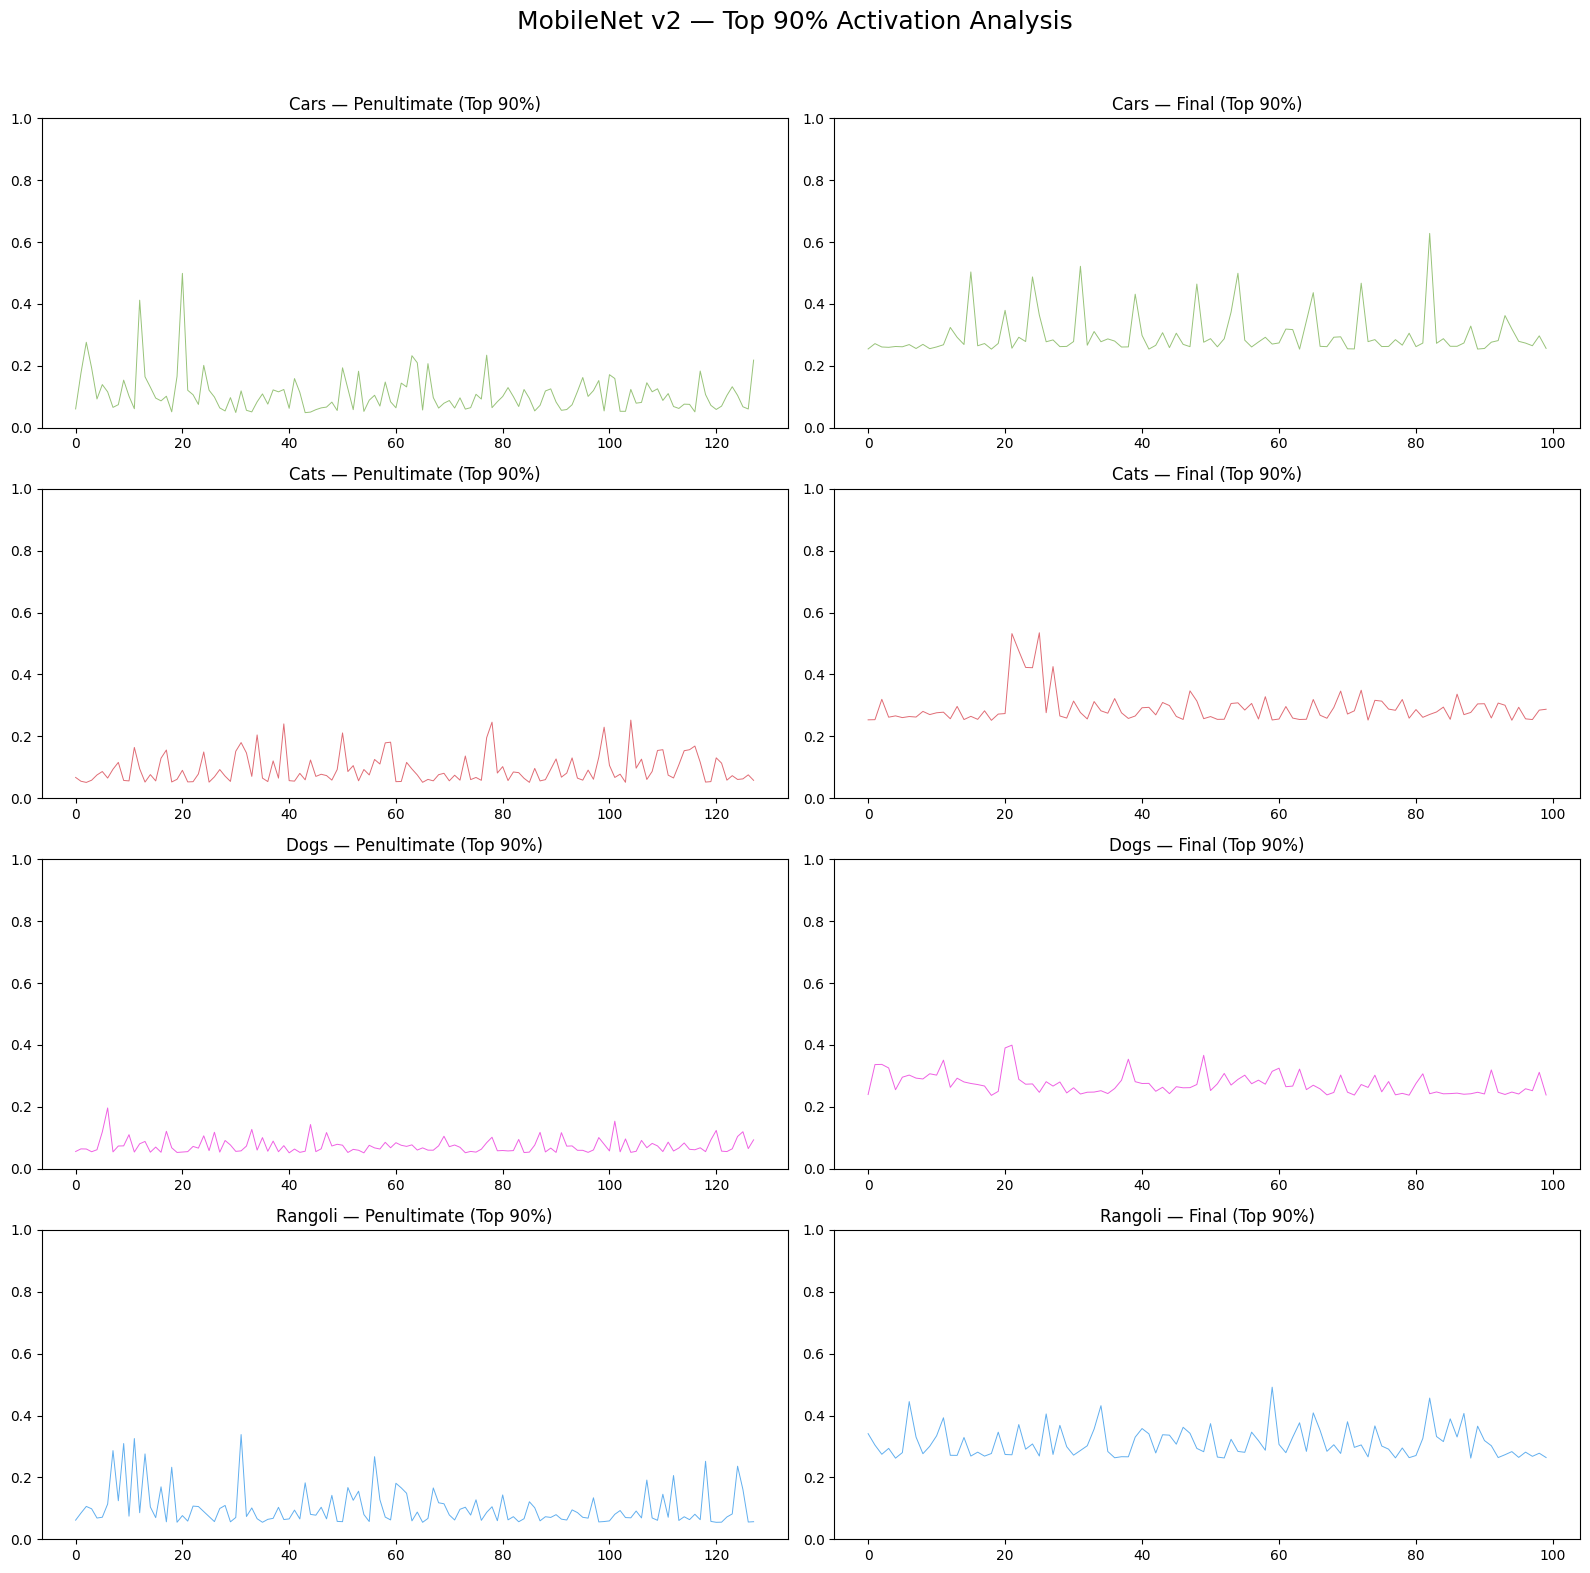


=== KL (TOP 90%) ===


--- Across Models ---

Class: Cats
ResNet50 || VGG16 : 14.4200
ResNet50 || Inception : 14.3794
ResNet50 || MobileNet : 14.2983
VGG16 || Inception : 12.4340
VGG16 || MobileNet : 10.2805
Inception || MobileNet : 18.6339

Class: Dogs
ResNet50 || VGG16 : 21.2438
ResNet50 || Inception : 13.1219
ResNet50 || MobileNet : 2.0431
VGG16 || Inception : 21.3031
VGG16 || MobileNet : 21.3031
Inception || MobileNet : 4.6129

Class: Cars
ResNet50 || VGG16 : 13.9112
ResNet50 || Inception : 9.9457
ResNet50 || MobileNet : 12.0181
VGG16 || Inception : 14.4200
VGG16 || MobileNet : 14.5586
Inception || MobileNet : 2.0723

Class: Rangoli
ResNet50 || VGG16 : 12.2548
ResNet50 || Inception : 12.3934
ResNet50 || MobileNet : 8.2488
VGG16 || Inception : 6.5466
VGG16 || MobileNet : 12.8329
Inception || MobileNet : 4.4742

--- Within Model ---

Model: ResNet50
Cats || Dogs : 16.6309
Cats || Cars : 16.6309
Cats || Rangoli : 18.6339
Dogs || Cars : 15.2348
Dogs || Rangoli : 14.9575
Cars || Rangol

In [8]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import itertools

from torchvision import models, transforms
from PIL import Image


# ─── CONFIG ──────────────────────────────────────────────────────────────────

DATASETS = {
    "Cars": "/Users/jaeeponde/Thesis/Data_100/Cars",
    "Cats": "/Users/jaeeponde/Thesis/Data_100/Cats",
    "Dogs": "/Users/jaeeponde/Thesis/Data_100/Dogs",
    "Rangoli": "/Users/jaeeponde/Thesis/Data_100/Rangoli"
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ─── TRANSFORMS ──────────────────────────────────────────────────────────────

transform_224 = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

transform_299 = transforms.Compose([
    transforms.Resize(342),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


# ─── HELPERS ─────────────────────────────────────────────────────────────────

def compute_hist_top(x, bins=50, eps=1e-8):
    thresh = np.percentile(x, 90)
    x = x[x >= thresh]
    if len(x) == 0:
        x = np.array([0.0])

    hist, _ = np.histogram(x, bins=bins, range=(0,1), density=True)
    hist = hist + eps
    return hist / hist.sum()

def kl(p, q):
    return np.sum(p * np.log(p / q))


# ─── EXTRACTION ──────────────────────────────────────────────────────────────

def extract(model, transform, hook_fn):

    activations = {"penultimate": [], "final": []}
    hook_fn(model, activations)

    model.to(DEVICE)
    model.eval()

    results = {}

    for label, folder in DATASETS.items():

        print(f"{model.__class__.__name__} → {label}")

        files = sorted([
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg",".png",".jpeg"))
        ])[:100]

        activations["penultimate"] = []
        activations["final"] = []

        for f in files:
            path = os.path.join(folder, f)

            try:
                img = Image.open(path).convert("RGB")
                x = transform(img).unsqueeze(0).to(DEVICE)

                with torch.no_grad():
                    model(x)

            except:
                continue

        results[label] = {
            "penultimate": np.concatenate(activations["penultimate"]),
            "final": np.concatenate(activations["final"])
        }

    return results


# ─── HOOKS ───────────────────────────────────────────────────────────────────

def hooks_resnet(model, acts):

    def pen(module, inp, out):
        acts["penultimate"].append(out.view(out.size(0), -1).cpu().numpy())

    def fin(module, inp, out):
        acts["final"].append(out.cpu().numpy())

    model.avgpool.register_forward_hook(pen)
    model.fc.register_forward_hook(fin)


def hooks_vgg(model, acts):

    def pen(module, inp, out):
        acts["penultimate"].append(out.cpu().numpy())

    def fin(module, inp, out):
        acts["final"].append(out.cpu().numpy())

    model.classifier[5].register_forward_hook(pen)
    model.classifier[6].register_forward_hook(fin)


def hooks_inception(model, acts):

    def pen(module, inp):
        acts["penultimate"].append(inp[0].cpu().numpy())

    def fin(module, inp, out):
        acts["final"].append(out.cpu().numpy())

    model.fc.register_forward_pre_hook(pen)
    model.fc.register_forward_hook(fin)


def hooks_mobilenet(model, acts):

    def pen(module, inp, out):
        pooled = out.mean([2,3])  # global avg pool
        acts["penultimate"].append(pooled.cpu().numpy())

    def fin(module, inp, out):
        acts["final"].append(out.cpu().numpy())

    model.features[-1].register_forward_hook(pen)
    model.classifier[1].register_forward_hook(fin)


# ─── NORMALIZATION + TOP 90% ─────────────────────────────────────────────────

def get_top90_global_neurons(all_class_acts):

    results = {}

    # normalization (same as before)
    all_pen = np.concatenate([v["penultimate"] for v in all_class_acts.values()])
    pen_max = max(all_pen.max(), 1e-6)

    all_fin = np.concatenate([v["final"] for v in all_class_acts.values()])
    fin_min, fin_max = all_fin.min(), all_fin.max()
    fin_range = max(fin_max - fin_min, 1e-6)

    for label, acts in all_class_acts.items():

        # normalize
        pen = acts["penultimate"] / pen_max
        fin = (acts["final"] - fin_min) / fin_range

        # 🔥 STEP 1: mean per neuron
        pen_mean = pen.mean(axis=0)
        fin_mean = fin.mean(axis=0)

        # 🔥 STEP 2: global threshold over neurons
        pen_thresh = np.percentile(pen_mean, 90)
        fin_thresh = np.percentile(fin_mean, 90)

        # 🔥 STEP 3: keep only top neurons
        pen_top = pen_mean[pen_mean >= pen_thresh]
        fin_top = fin_mean[fin_mean >= fin_thresh]

        results[label] = {
            "penultimate": pen_top,
            "final": fin_top
        }

    return results


# ─── PLOTTING ────────────────────────────────────────────────────────────────

def plot(model_name, data):

    colors = {
        "Cars": "#98C379",
        "Cats": "#E06C75",
        "Dogs": "#EF61E3",
        "Rangoli": "#61AFEF"
    }

    labels = list(data.keys())
    fig, axes = plt.subplots(len(labels), 2, figsize=(16, 4*len(labels)))

    for i, label in enumerate(labels):

        c = colors[label]

        ax1 = axes[i,0]
        ax2 = axes[i,1]

        ax1.plot(data[label]["penultimate"], color=c, linewidth=0.7)
        ax1.set_ylim(0,1)
        ax1.set_title(f"{label} — Penultimate (Top 90%)")

        ax2.plot(data[label]["final"], color=c, linewidth=0.7)
        ax2.set_ylim(0,1)
        ax2.set_title(f"{label} — Final (Top 90%)")

    plt.suptitle(f"{model_name} — Top 90% Activation Analysis", fontsize=18)
    plt.tight_layout(rect=[0,0,1,0.96])
    plt.show()


# ─── KL ──────────────────────────────────────────────────────────────────────

def compute_kl(models_dict, layer="final"):

    classes = ["Cats","Dogs","Cars","Rangoli"]

    print("\n=== KL (TOP 90%) ===\n")

    # Across models
    print("\n--- Across Models ---")

    for cls in classes:

        print(f"\nClass: {cls}")

        hists = {}
        for m, data in models_dict.items():
            vec = data[cls][layer].flatten()
            hists[m] = compute_hist_top(vec)

        for m1, m2 in itertools.combinations(models_dict.keys(), 2):
            print(f"{m1} || {m2} : {kl(hists[m1], hists[m2]):.4f}")

    # Within model
    print("\n--- Within Model ---")

    for m, data in models_dict.items():

        print(f"\nModel: {m}")

        hists = {}
        for cls in classes:
            vec = data[cls][layer].flatten()
            hists[cls] = compute_hist_top(vec)

        for c1, c2 in itertools.combinations(classes, 2):
            print(f"{c1} || {c2} : {kl(hists[c1], hists[c2]):.4f}")


# ─── MAIN ────────────────────────────────────────────────────────────────────

def main():

    # Load models
    resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

    inception = models.inception_v3(
        weights=models.Inception_V3_Weights.DEFAULT,
        aux_logits=True
    )
    inception.AuxLogits = None

    mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

    # Extract
    resnet_data = extract(resnet, transform_224, hooks_resnet)
    vgg_data = extract(vgg, transform_224, hooks_vgg)
    inception_data = extract(inception, transform_299, hooks_inception)
    mobilenet_data = extract(mobilenet, transform_224, hooks_mobilenet)

    # Top 90
    resnet_top = get_top90_global_neurons(resnet_data)
    vgg_top = get_top90_global_neurons(vgg_data)
    inception_top = get_top90_global_neurons(inception_data)
    mobilenet_top = get_top90_global_neurons(mobilenet_data)

    # Plot
    plot("ResNet50", resnet_top)
    plot("VGG16", vgg_top)
    plot("Inception v3", inception_top)
    plot("MobileNet v2", mobilenet_top)

    # KL
    models_dict = {
        "ResNet50": resnet_top,
        "VGG16": vgg_top,
        "Inception": inception_top,
        "MobileNet": mobilenet_top
    }

    compute_kl(models_dict)


if __name__ == "__main__":
    main()

Device: cpu
ResNet → Cars
ResNet → Cats
ResNet → Dogs
ResNet → Rangoli


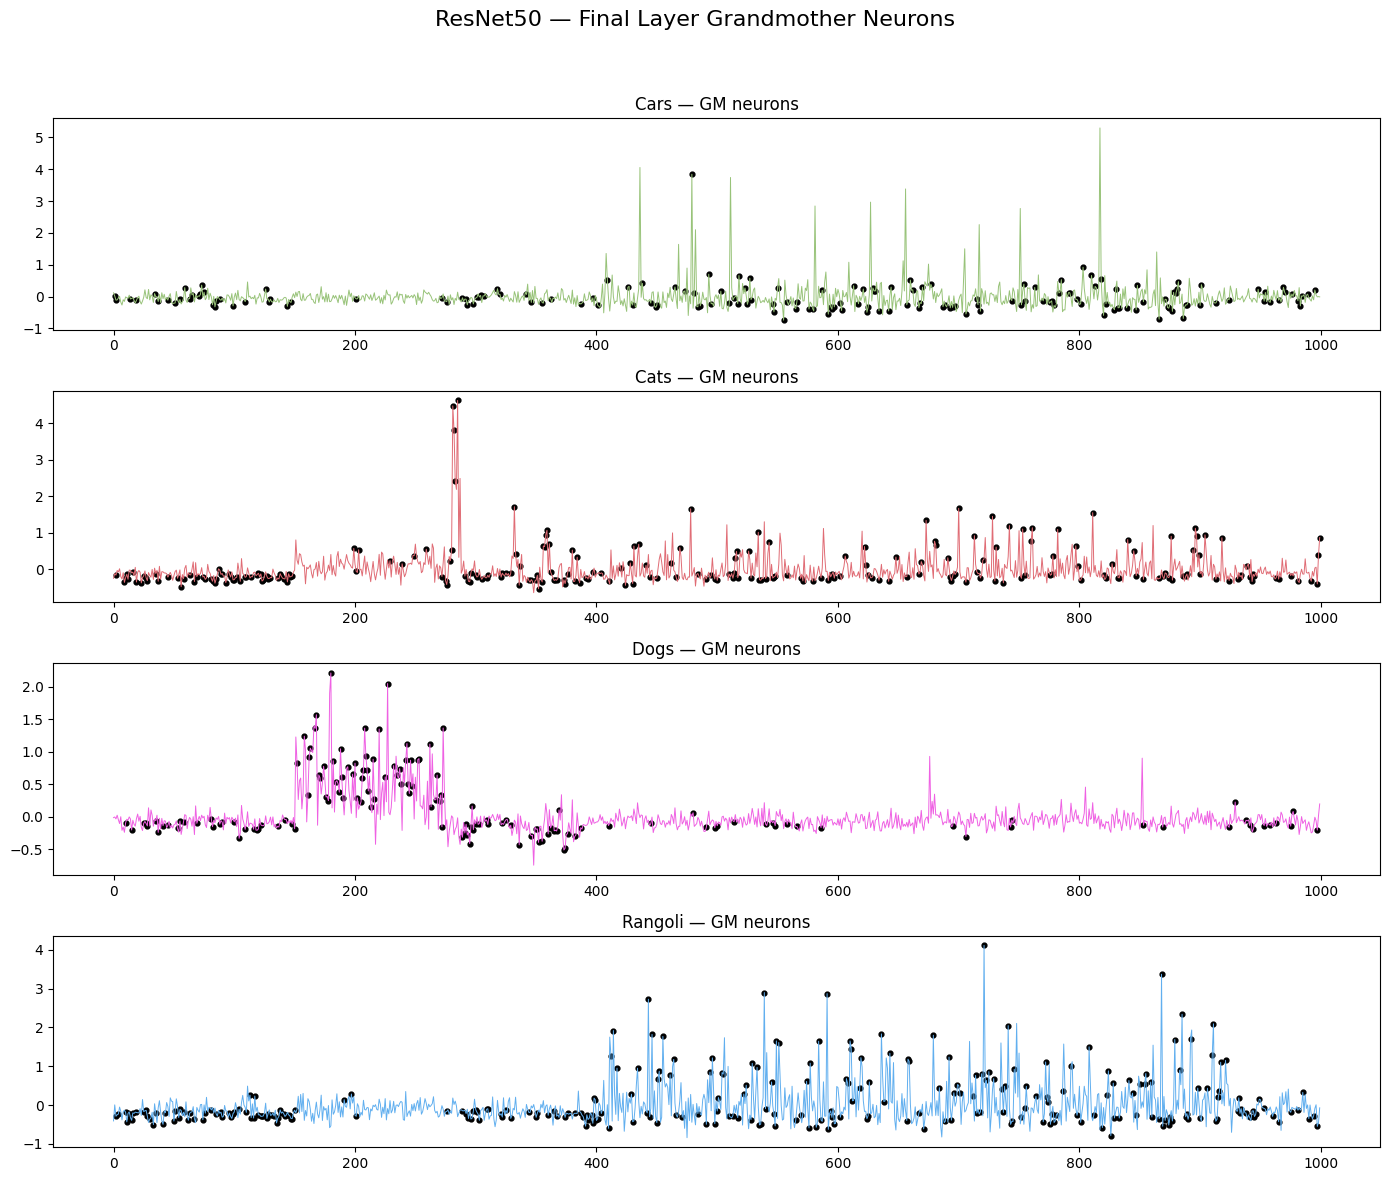

VGG → Cars
VGG → Cats
VGG → Dogs
VGG → Rangoli


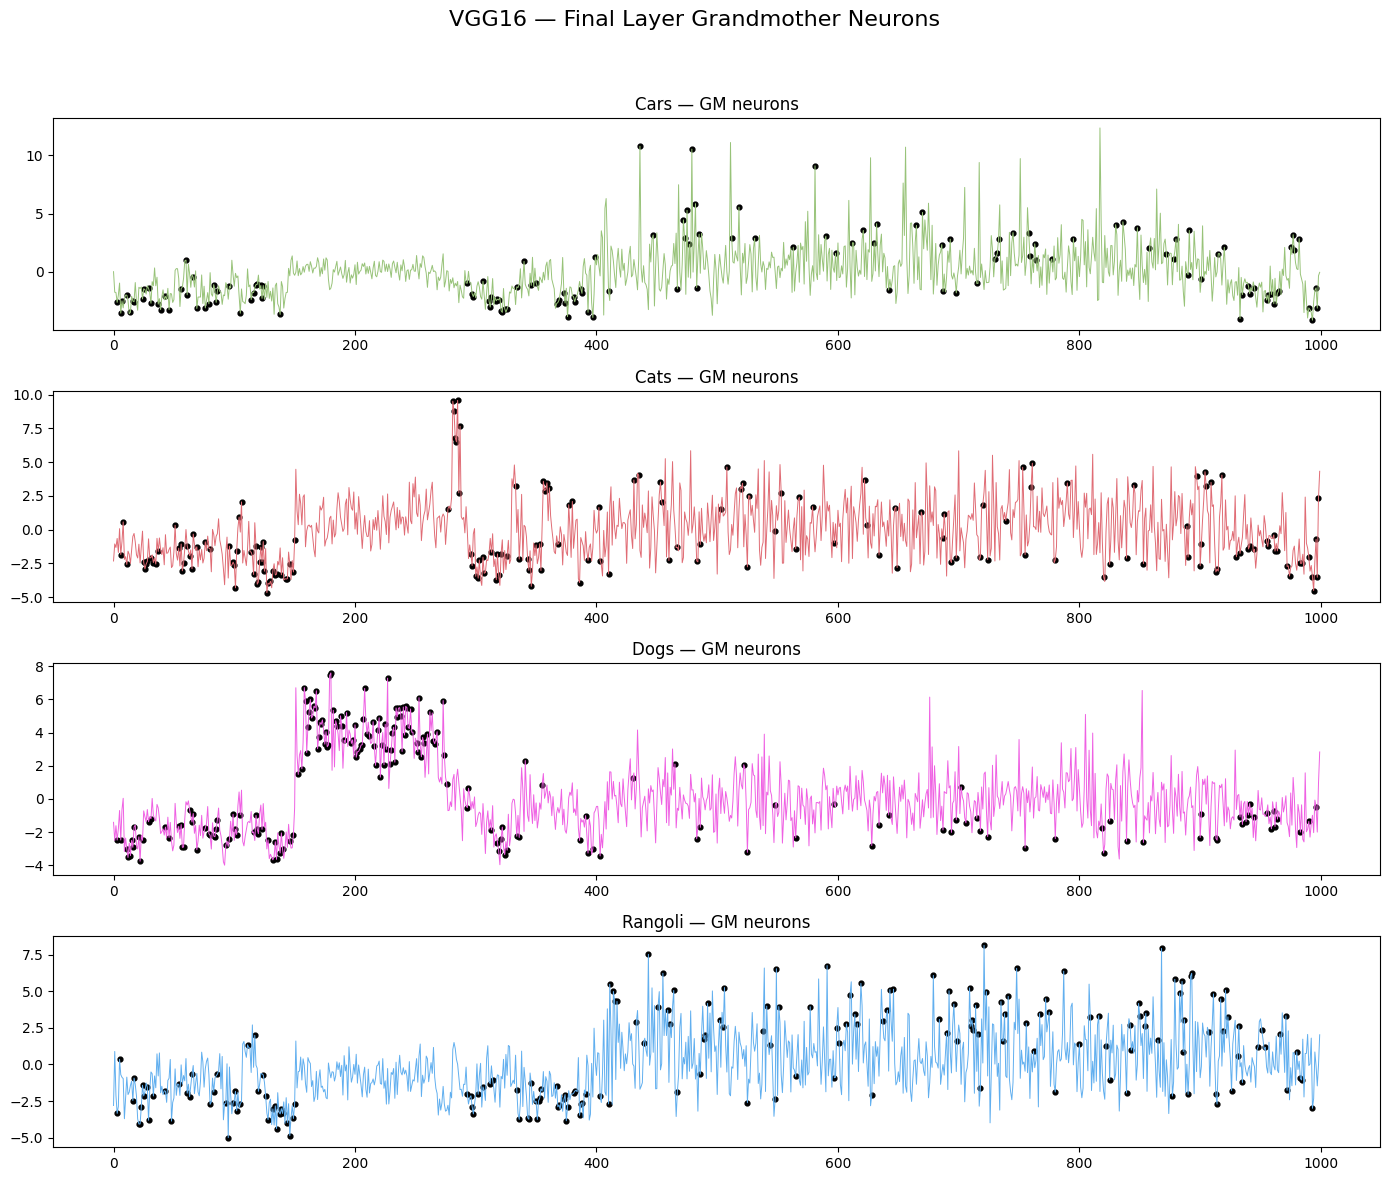

Inception3 → Cars
Inception3 → Cats
Inception3 → Dogs
Inception3 → Rangoli


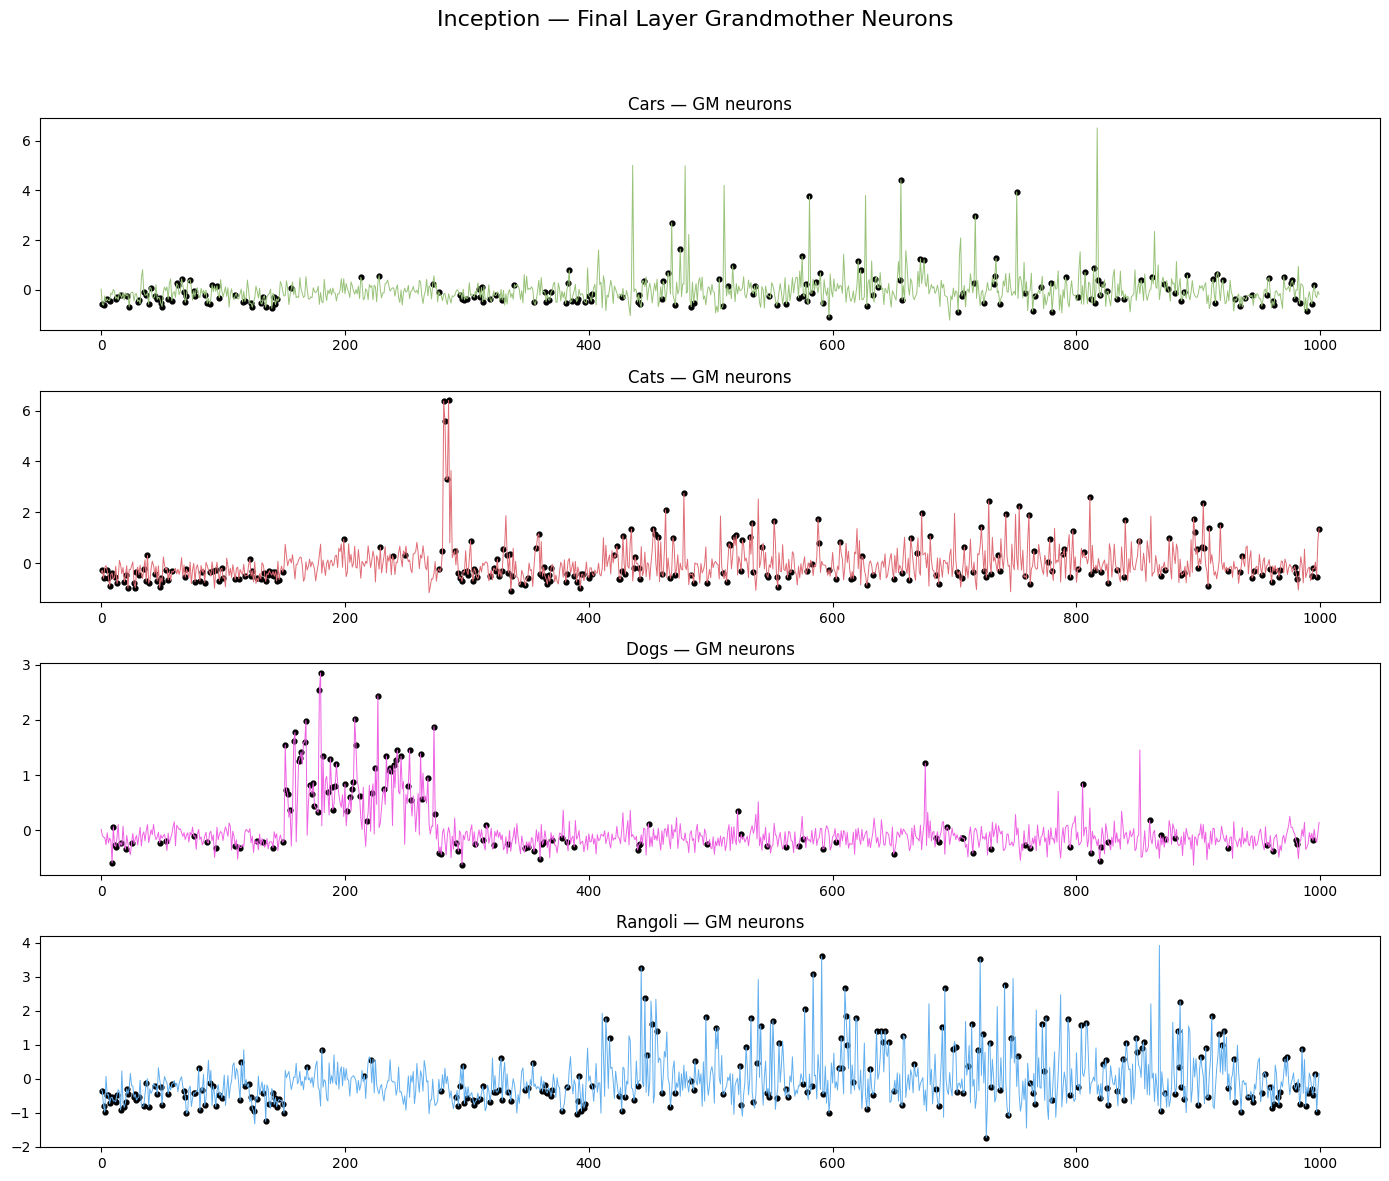

MobileNetV2 → Cars
MobileNetV2 → Cats
MobileNetV2 → Dogs
MobileNetV2 → Rangoli


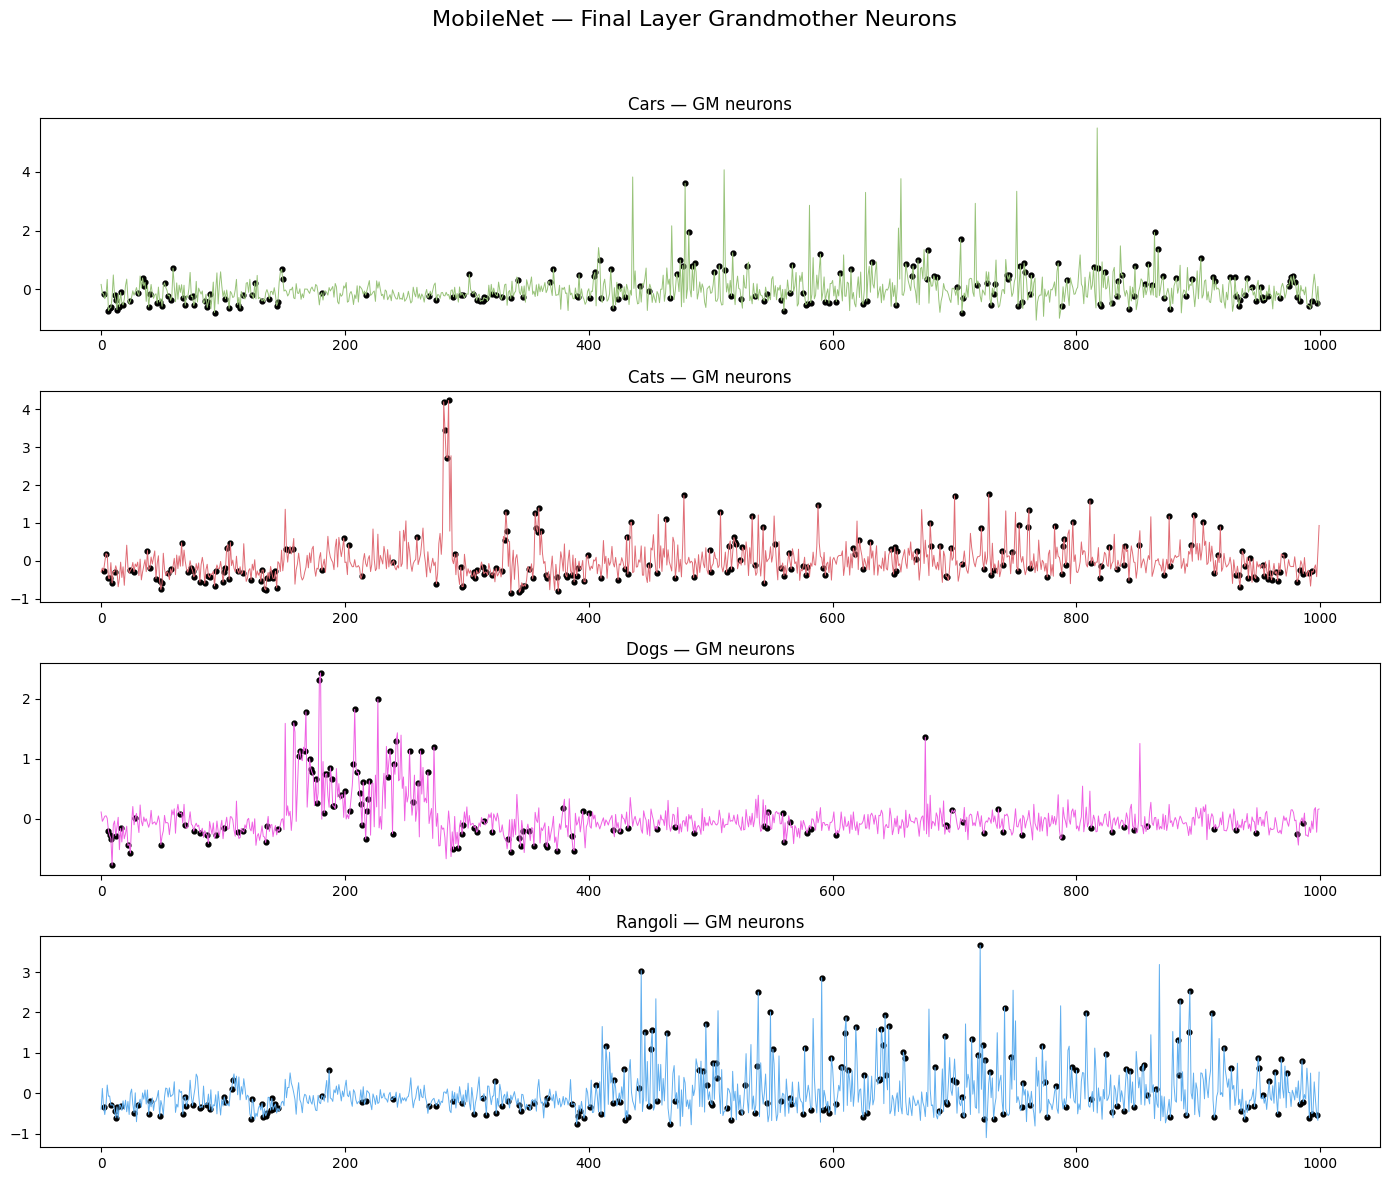


=== GM OVERLAP ACROSS MODELS ===


Class: Cats
ResNet50 vs VGG16: 78 overlap
ResNet50 vs Inception: 113 overlap
ResNet50 vs MobileNet: 105 overlap
VGG16 vs Inception: 75 overlap
VGG16 vs MobileNet: 69 overlap
Inception vs MobileNet: 101 overlap

Class: Dogs
ResNet50 vs VGG16: 57 overlap
ResNet50 vs Inception: 50 overlap
ResNet50 vs MobileNet: 45 overlap
VGG16 vs Inception: 63 overlap
VGG16 vs MobileNet: 65 overlap
Inception vs MobileNet: 44 overlap

Class: Cars
ResNet50 vs VGG16: 27 overlap
ResNet50 vs Inception: 43 overlap
ResNet50 vs MobileNet: 56 overlap
VGG16 vs Inception: 42 overlap
VGG16 vs MobileNet: 52 overlap
Inception vs MobileNet: 59 overlap

Class: Rangoli
ResNet50 vs VGG16: 80 overlap
ResNet50 vs Inception: 122 overlap
ResNet50 vs MobileNet: 114 overlap
VGG16 vs Inception: 83 overlap
VGG16 vs MobileNet: 69 overlap
Inception vs MobileNet: 94 overlap


In [16]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import models, transforms
from PIL import Image


# ==============================
# CONFIG
# ==============================

DATASETS = {
    "Cars": "/Users/jaeeponde/Thesis/Data_100/Cars",
    "Cats": "/Users/jaeeponde/Thesis/Data_100/Cats",
    "Dogs": "/Users/jaeeponde/Thesis/Data_100/Dogs",
    "Rangoli": "/Users/jaeeponde/Thesis/Data_100/Rangoli"
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform_224 = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

transform_299 = transforms.Compose([
    transforms.Resize(342),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])


# ==============================
# MODEL LOADERS
# ==============================

def load_resnet():
    return models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

def load_vgg():
    return models.vgg16(weights=models.VGG16_Weights.DEFAULT)

def load_inception():
    model = models.inception_v3(
        weights=models.Inception_V3_Weights.DEFAULT,
        aux_logits=True
    )
    model.AuxLogits = None
    return model

def load_mobilenet():
    return models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)


# ==============================
# EXTRACTION (FINAL LAYER ONLY)
# ==============================

def extract_final_activations(model, transform):

    activations = []

    def hook(module, inp, out):
        activations.append(out.detach().cpu().numpy())

    # attach hook to final classifier layer
    if isinstance(model, models.ResNet):
        model.fc.register_forward_hook(hook)

    elif isinstance(model, models.VGG):
        model.classifier[6].register_forward_hook(hook)

    elif isinstance(model, models.Inception3):
        model.fc.register_forward_hook(hook)

    elif isinstance(model, models.MobileNetV2):
        model.classifier[1].register_forward_hook(hook)

    model.to(DEVICE)
    model.eval()

    results = {}

    for label, folder in DATASETS.items():

        print(f"{model.__class__.__name__} → {label}")

        activations.clear()

        files = sorted([
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg",".png",".jpeg"))
        ])[:100]

        for fname in files:

            path = os.path.join(folder, fname)

            try:
                img = Image.open(path).convert("RGB")
                x = transform(img).unsqueeze(0).to(DEVICE)

                with torch.no_grad():
                    model(x)

            except:
                continue

        results[label] = np.concatenate(activations, axis=0)

    return results


# ==============================
# GRANDMOTHER NEURONS
# ==============================

def compute_selectivity(data):

    classes = list(data.keys())

    means = {cls: data[cls].mean(axis=0) for cls in classes}

    selectivity = {}

    for cls in classes:
        others = [c for c in classes if c != cls]
        other_max = np.max([means[o] for o in others], axis=0)

        selectivity[cls] = means[cls] / (other_max + 1e-8)

    return selectivity


def get_grandmother_neurons(selectivity, threshold=2.0):

    gm = {}

    for cls, scores in selectivity.items():
        gm[cls] = np.where(scores >= threshold)[0]

    return gm


# ==============================
# PLOTTING
# ==============================

def plot_gm(model_name, data, gm):

    colors = {
        "Cars": "#98C379",
        "Cats": "#E06C75",
        "Dogs": "#EF61E3",
        "Rangoli": "#61AFEF"
    }

    classes = list(data.keys())

    fig, axes = plt.subplots(len(classes), 1, figsize=(14, 3*len(classes)))

    for i, cls in enumerate(classes):

        ax = axes[i] if len(classes) > 1 else axes

        vec = data[cls].mean(axis=0)

        ax.plot(vec, color=colors[cls], linewidth=0.7)

        idx = gm[cls]
        ax.scatter(idx, vec[idx], color="black", s=12)

        ax.set_title(f"{cls} — GM neurons")

    plt.suptitle(f"{model_name} — Final Layer Grandmother Neurons", fontsize=16)
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()


# ==============================
# OVERLAP COMPARISON
# ==============================

def compare_overlap(all_gm):

    classes = ["Cats","Dogs","Cars","Rangoli"]

    print("\n=== GM OVERLAP ACROSS MODELS ===\n")

    for cls in classes:

        print(f"\nClass: {cls}")

        models = list(all_gm.keys())

        for i in range(len(models)):
            for j in range(i+1, len(models)):

                m1, m2 = models[i], models[j]

                s1 = set(all_gm[m1][cls])
                s2 = set(all_gm[m2][cls])

                print(f"{m1} vs {m2}: {len(s1 & s2)} overlap")


# ==============================
# MAIN
# ==============================

def main():

    print("Device:", DEVICE)

    models_dict = {
        "ResNet50": (load_resnet(), transform_224),
        "VGG16": (load_vgg(), transform_224),
        "Inception": (load_inception(), transform_299),
        "MobileNet": (load_mobilenet(), transform_224)
    }

    all_gm = {}

    for model_name, (model, transform) in models_dict.items():

        data = extract_final_activations(model, transform)

        selectivity = compute_selectivity(data)
        gm = get_grandmother_neurons(selectivity, threshold=2.0)

        all_gm[model_name] = gm

        plot_gm(model_name, data, gm)

    compare_overlap(all_gm)


if __name__ == "__main__":
    main()

In [17]:
def compute_overlap_metrics(gm_all):

    classes = ["Cats","Dogs","Cars","Rangoli"]

    print("\n=== NORMALIZED GM OVERLAP (JACCARD) ===\n")

    for cls in classes:

        print(f"\nClass: {cls}")

        models = list(gm_all.keys())

        for i in range(len(models)):
            for j in range(i+1, len(models)):

                m1, m2 = models[i], models[j]

                s1 = set(gm_all[m1][cls])
                s2 = set(gm_all[m2][cls])

                inter = len(s1 & s2)
                union = len(s1 | s2)

                jaccard = inter / union if union > 0 else 0

                print(f"{m1} vs {m2}: "
                      f"overlap={inter}, total={union}, J={jaccard:.4f}")

In [18]:
def plot_gm_overlay_histograms(models_data, gm_all):

    colors = {
        "ResNet50": "#E06C75",
        "VGG16": "#61AFEF",
        "Inception": "#98C379",
        "MobileNet": "#C678DD"
    }

    classes = ["Cats","Dogs","Cars","Rangoli"]

    for cls in classes:

        plt.figure(figsize=(12,4))

        for model_name, data in models_data.items():

            vec = data[cls].mean(axis=0)
            gm_idx = gm_all[model_name][cls]

            if len(gm_idx) == 0:
                continue

            # only GM neurons
            x = gm_idx
            y = vec[gm_idx]

            plt.scatter(x, y,
                        label=model_name,
                        color=colors[model_name],
                        s=20,
                        alpha=0.7)

        plt.title(f"GM Neuron Overlay — {cls}")
        plt.xlabel("Neuron Index")
        plt.ylabel("Activation")
        plt.legend()
        plt.tight_layout()
        plt.show()

In [38]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import models, transforms
from PIL import Image


# ==============================
# CONFIG
# ==============================

DATASETS = {
    "Cars": "/Users/jaeeponde/Thesis/Data_100/Cars",
    "Cats": "/Users/jaeeponde/Thesis/Data_100/Cats",
    "Dogs": "/Users/jaeeponde/Thesis/Data_100/Dogs",
    "Rangoli": "/Users/jaeeponde/Thesis/Data_100/Rangoli"
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform_224 = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

transform_299 = transforms.Compose([
    transforms.Resize(342),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])


# ==============================
# MODEL LOADERS
# ==============================

def load_resnet():
    return models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

def load_vgg():
    return models.vgg16(weights=models.VGG16_Weights.DEFAULT)

def load_inception():
    model = models.inception_v3(
        weights=models.Inception_V3_Weights.DEFAULT,
        aux_logits=True
    )
    model.AuxLogits = None
    return model

def load_mobilenet():
    return models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)


# ==============================
# EXTRACTION (FINAL LAYER ONLY)
# ==============================

def extract_final_activations(model, transform):

    activations = []

    def hook(module, inp, out):
        activations.append(out.detach().cpu().numpy())

    # attach hook to final classifier layer
    if isinstance(model, models.ResNet):
        model.fc.register_forward_hook(hook)

    elif isinstance(model, models.VGG):
        model.classifier[6].register_forward_hook(hook)

    elif isinstance(model, models.Inception3):
        model.fc.register_forward_hook(hook)

    elif isinstance(model, models.MobileNetV2):
        model.classifier[1].register_forward_hook(hook)

    model.to(DEVICE)
    model.eval()

    results = {}

    for label, folder in DATASETS.items():

        print(f"{model.__class__.__name__} → {label}")

        activations.clear()

        files = sorted([
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg",".png",".jpeg"))
        ])[:100]

        for fname in files:

            path = os.path.join(folder, fname)

            try:
                img = Image.open(path).convert("RGB")
                x = transform(img).unsqueeze(0).to(DEVICE)

                with torch.no_grad():
                    model(x)

            except:
                continue

        results[label] = np.concatenate(activations, axis=0)

    return results


# ==============================
# GRANDMOTHER NEURONS
# ==============================

def compute_selectivity(data):

    classes = list(data.keys())

    means = {cls: data[cls].mean(axis=0) for cls in classes}

    selectivity = {}

    for cls in classes:
        others = [c for c in classes if c != cls]
        other_max = np.max([means[o] for o in others], axis=0)

        selectivity[cls] = means[cls] / (other_max + 1e-8)

    return selectivity


def get_grandmother_neurons(selectivity, threshold=2.0):

    gm = {}

    for cls, scores in selectivity.items():
        gm[cls] = np.where(scores >= threshold)[0]

    return gm


# ==============================
# PLOTTING
# ==============================

def plot_topk(model_name, data, k=50):

    colors = {
        "Cars": "#98C379",
        "Cats": "#E06C75",
        "Dogs": "#EF61E3",
        "Rangoli": "#61AFEF"
    }

    classes = list(data.keys())

    fig, axes = plt.subplots(len(classes), 1, figsize=(14, 3*len(classes)))

    for i, cls in enumerate(classes):

        ax = axes[i] if len(classes) > 1 else axes

        vec = data[cls].mean(axis=0)

        # 🔥 TOP-K neurons
        topk_idx = np.argsort(vec)[-k:]

        ax.plot(vec, color=colors[cls], linewidth=0.7)

        # 🔥 highlight top-k
        ax.scatter(topk_idx, vec[topk_idx], color="black", s=12)

        ax.set_title(f"{cls} — Top {k} Neurons")

    plt.suptitle(f"{model_name} — Top {k} Neurons (Final Layer)", fontsize=16)
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()


# ==============================
# OVERLAP COMPARISON
# ==============================

def compare_overlap(all_gm):

    classes = ["Cats","Dogs","Cars","Rangoli"]

    print("\n=== GM OVERLAP ACROSS MODELS ===\n")

    for cls in classes:

        print(f"\nClass: {cls}")

        models = list(all_gm.keys())

        for i in range(len(models)):
            for j in range(i+1, len(models)):

                m1, m2 = models[i], models[j]

                s1 = set(all_gm[m1][cls])
                s2 = set(all_gm[m2][cls])

                print(f"{m1} vs {m2}: {len(s1 & s2)} overlap")


# ==============================
# MAIN
# ==============================

def main():

    print("Device:", DEVICE)

    models_dict = {
        "ResNet50": (load_resnet(), transform_224),
        "VGG16": (load_vgg(), transform_224),
        "Inception": (load_inception(), transform_299),
        "MobileNet": (load_mobilenet(), transform_224)
    }

    all_gm = {}
    models_data = {}

    for model_name, (model, transform) in models_dict.items():

        data = extract_final_activations(model, transform)

        models_data[model_name] = data   # 🔥 store this

        selectivity = compute_selectivity(data)
        gm = get_grandmother_neurons(selectivity, threshold=8.0)

        all_gm[model_name] = gm

        plot_topk(model_name, data, k=50)

    compare_overlap(all_gm)

    # 🔥 RETURN EVERYTHING
    return models_data, all_gm

Device: cpu
ResNet → Cars
ResNet → Cats
ResNet → Dogs
ResNet → Rangoli


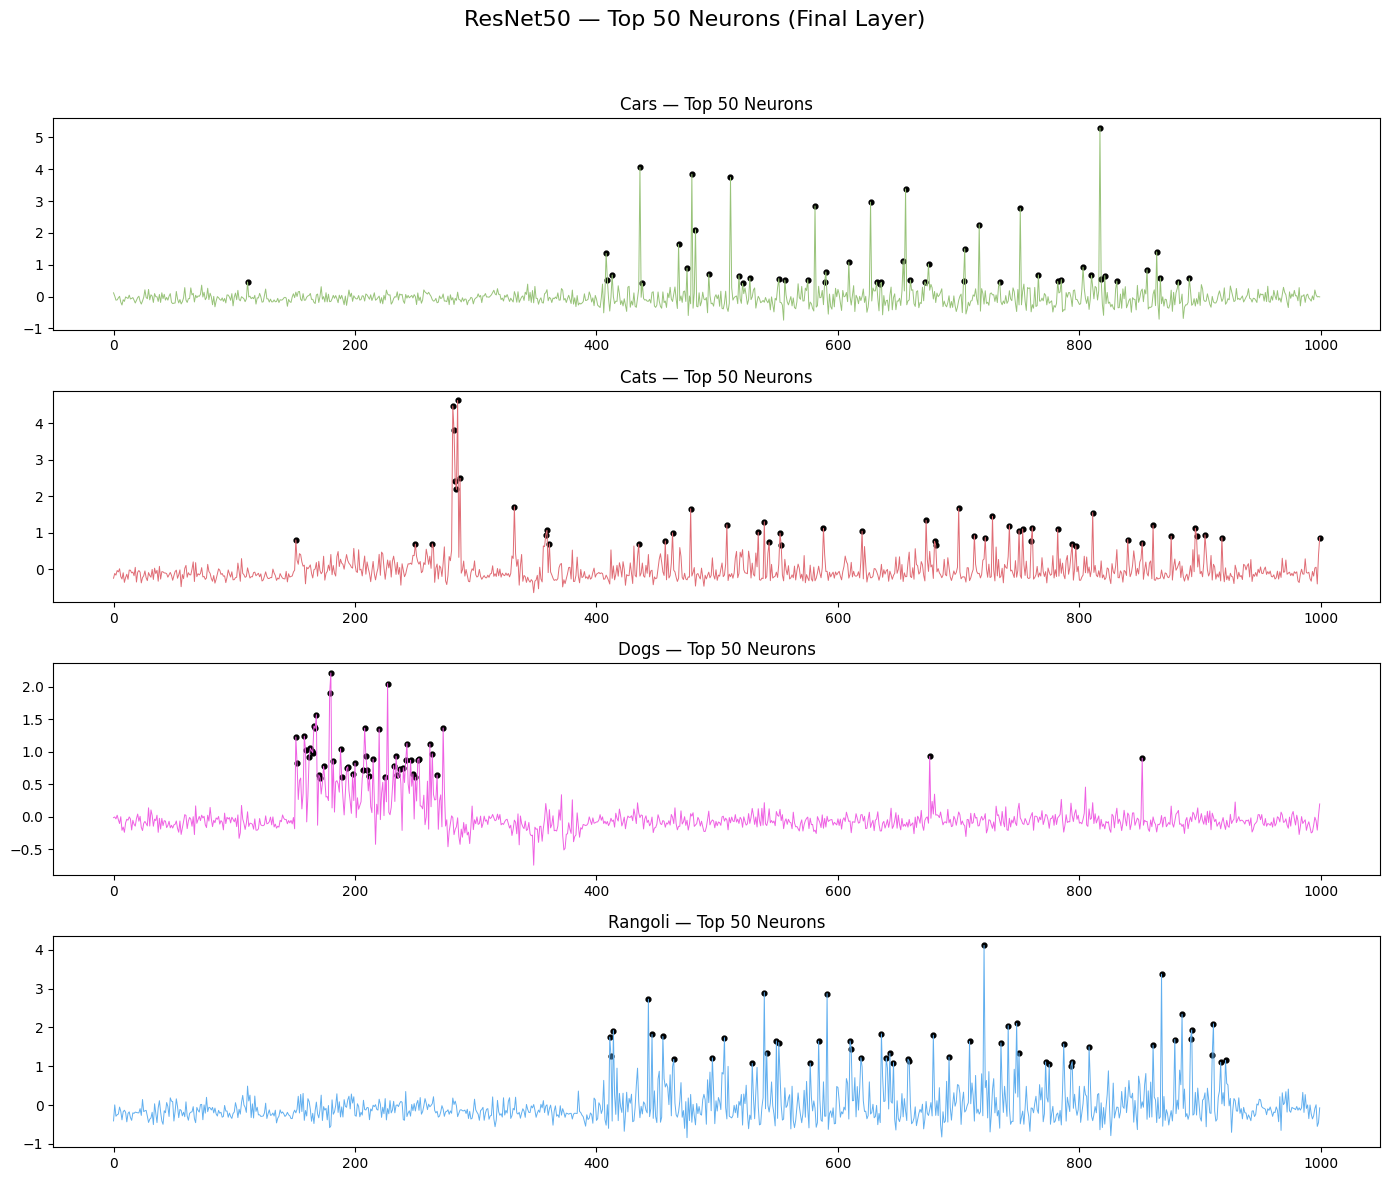

VGG → Cars
VGG → Cats
VGG → Dogs
VGG → Rangoli


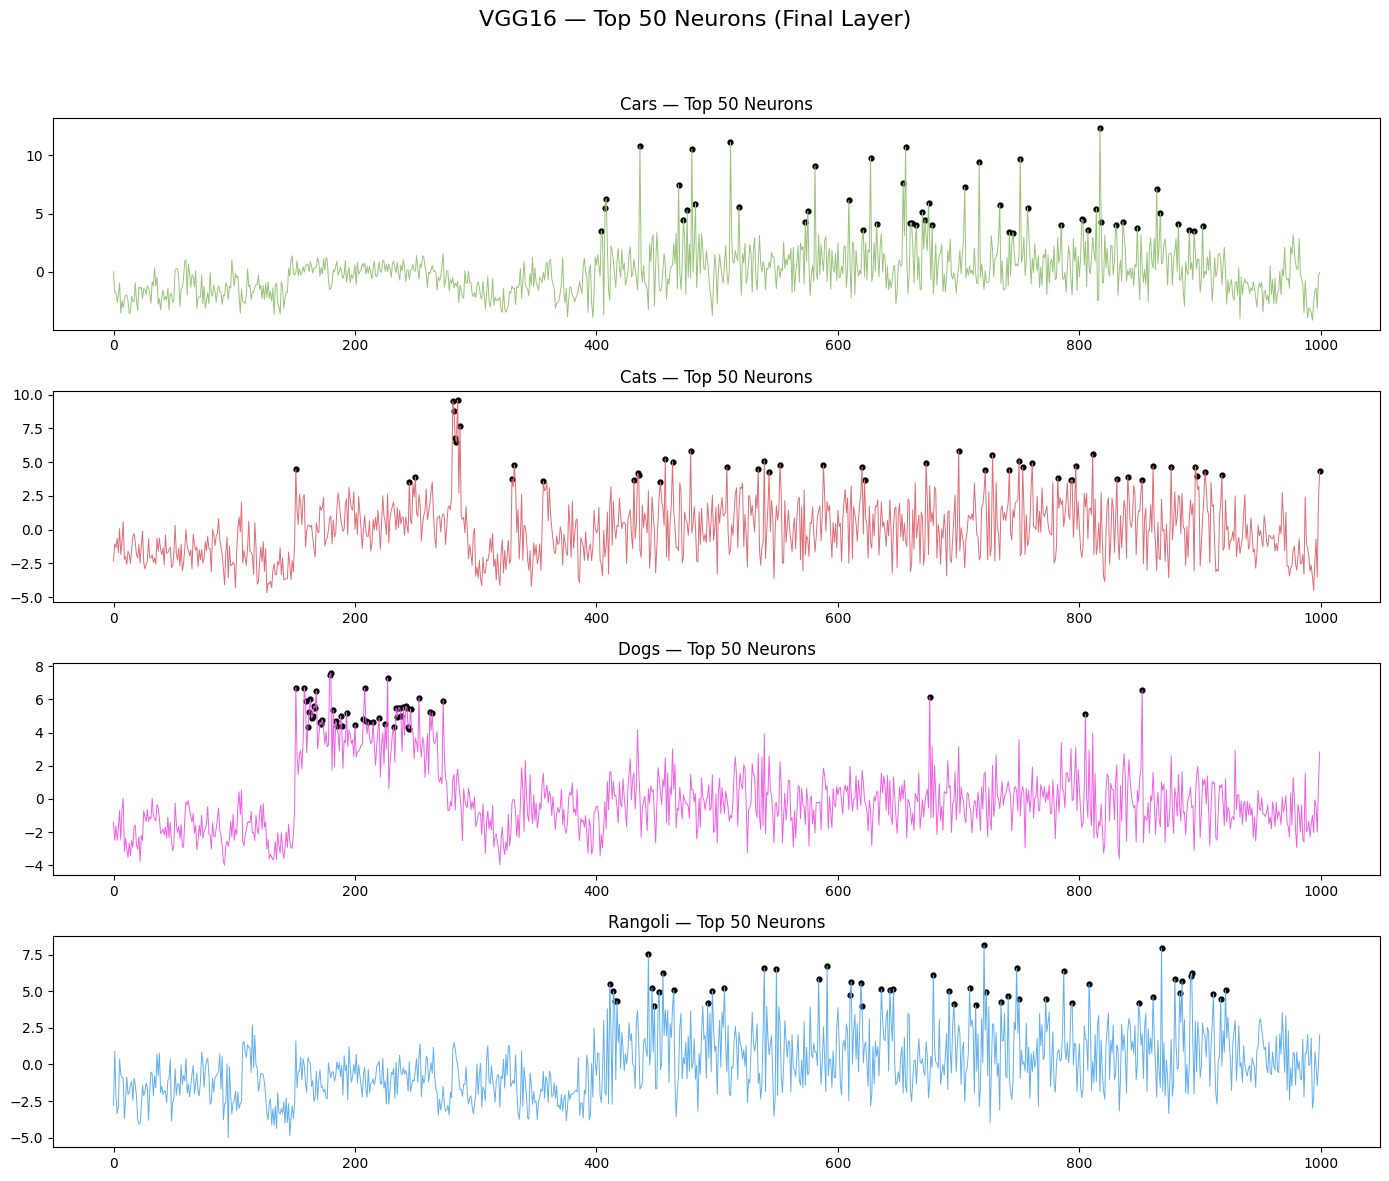

Inception3 → Cars
Inception3 → Cats
Inception3 → Dogs
Inception3 → Rangoli


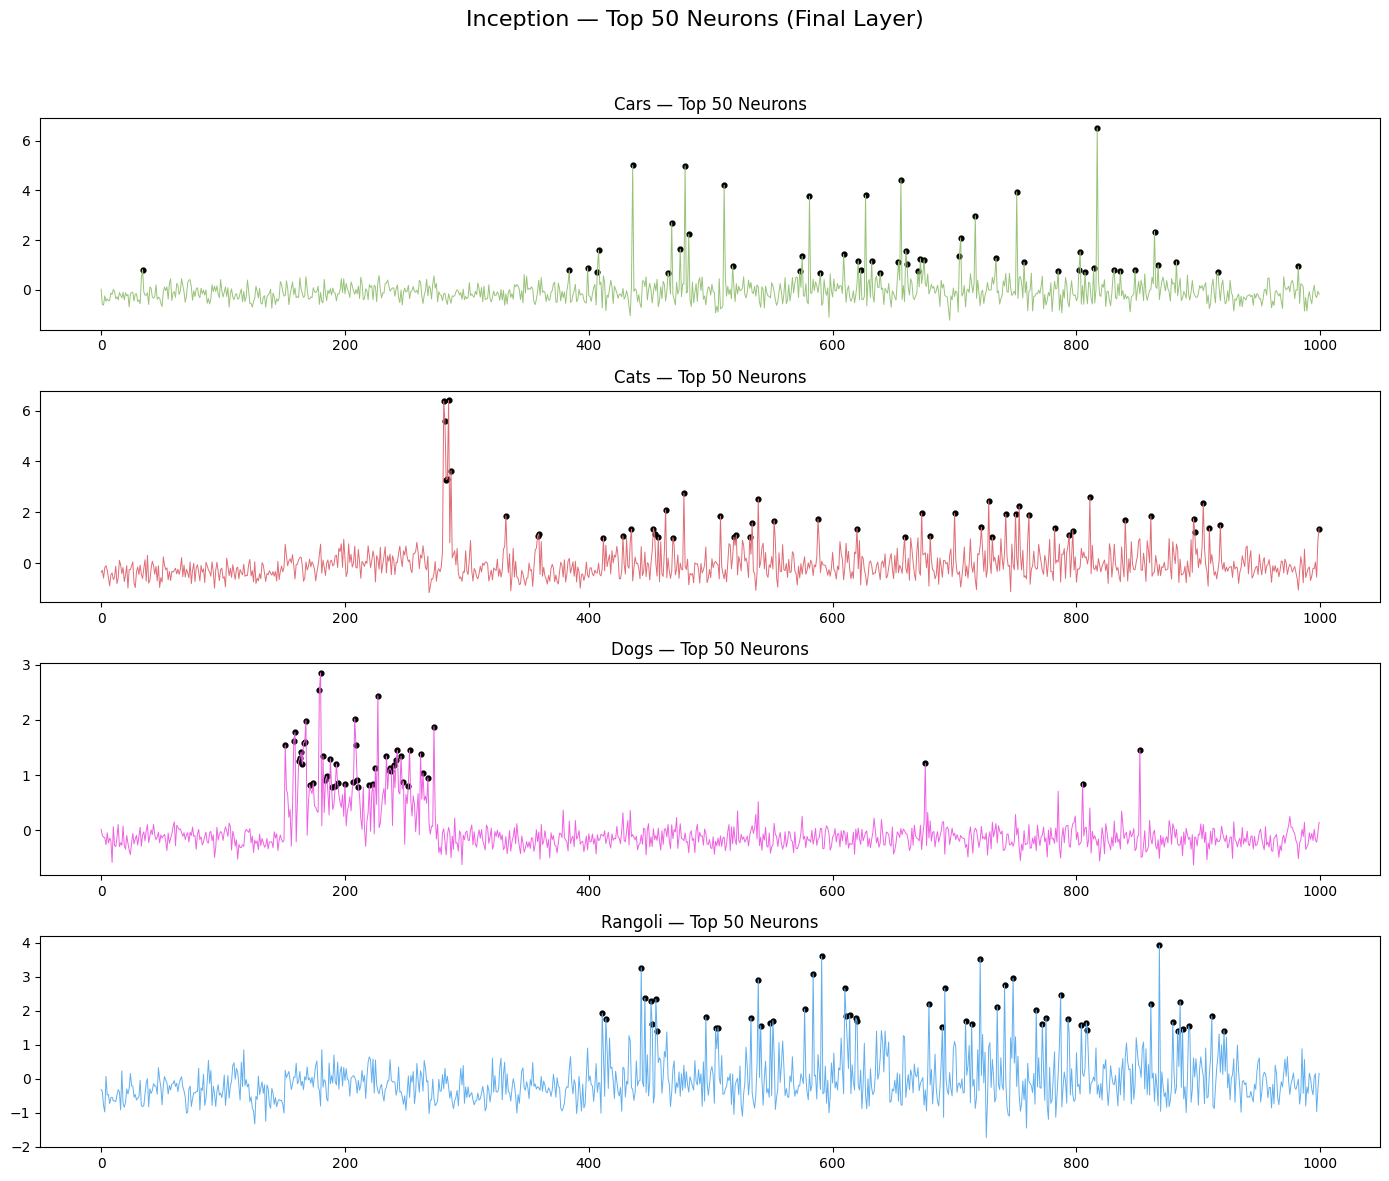

MobileNetV2 → Cars
MobileNetV2 → Cats
MobileNetV2 → Dogs
MobileNetV2 → Rangoli


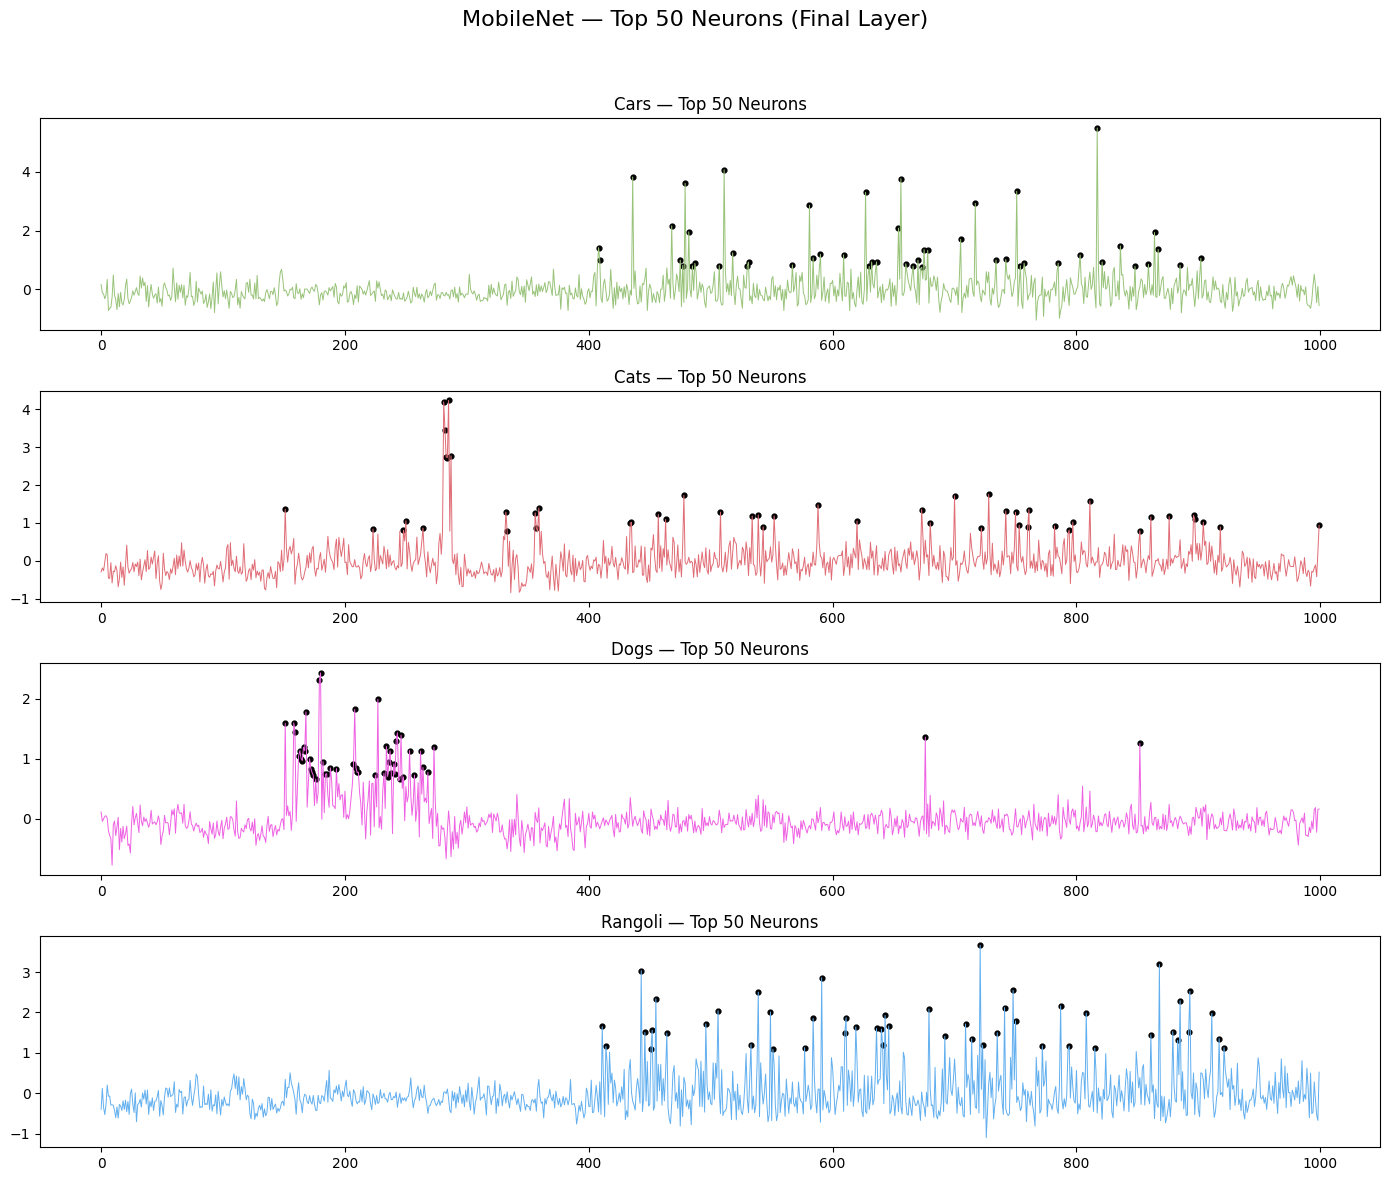


=== GM OVERLAP ACROSS MODELS ===


Class: Cats
ResNet50 vs VGG16: 4 overlap
ResNet50 vs Inception: 11 overlap
ResNet50 vs MobileNet: 11 overlap
VGG16 vs Inception: 7 overlap
VGG16 vs MobileNet: 7 overlap
Inception vs MobileNet: 12 overlap

Class: Dogs
ResNet50 vs VGG16: 6 overlap
ResNet50 vs Inception: 7 overlap
ResNet50 vs MobileNet: 6 overlap
VGG16 vs Inception: 8 overlap
VGG16 vs MobileNet: 7 overlap
Inception vs MobileNet: 6 overlap

Class: Cars
ResNet50 vs VGG16: 2 overlap
ResNet50 vs Inception: 3 overlap
ResNet50 vs MobileNet: 6 overlap
VGG16 vs Inception: 4 overlap
VGG16 vs MobileNet: 9 overlap
Inception vs MobileNet: 9 overlap

Class: Rangoli
ResNet50 vs VGG16: 3 overlap
ResNet50 vs Inception: 17 overlap
ResNet50 vs MobileNet: 16 overlap
VGG16 vs Inception: 9 overlap
VGG16 vs MobileNet: 2 overlap
Inception vs MobileNet: 10 overlap


In [39]:
models_data, gm_all = main()

In [44]:
def compute_topk_overlap(models_data, k=10):

    classes = ["Cats","Dogs","Cars","Rangoli"]

    print(f"\n=== TOP-{k} NEURON OVERLAP (%) ===\n")

    for cls in classes:

        print(f"\nClass: {cls}")

        topk_sets = {}

        for model_name, data in models_data.items():

            vec = data[cls].mean(axis=0)
            idx = np.argsort(vec)[-k:]

            topk_sets[model_name] = set(idx)

        models = list(topk_sets.keys())

        for i in range(len(models)):
            for j in range(i+1, len(models)):

                m1, m2 = models[i], models[j]

                inter = len(topk_sets[m1] & topk_sets[m2])

                percent = (inter / k) * 100

                print(f"{m1} vs {m2}: {percent:.2f}% overlap")

In [32]:
from scipy.stats import spearmanr

def compute_rank_correlation(models_data):

    classes = ["Cats","Dogs","Cars","Rangoli"]

    print("\n=== RANK CORRELATION (SPEARMAN) ===\n")

    for cls in classes:

        print(f"\nClass: {cls}")

        models = list(models_data.keys())

        for i in range(len(models)):
            for j in range(i+1, len(models)):

                m1, m2 = models[i], models[j]

                v1 = models_data[m1][cls].mean(axis=0)
                v2 = models_data[m2][cls].mean(axis=0)

                corr, _ = spearmanr(v1, v2)

                print(f"{m1} vs {m2}: {corr:.4f}")

In [34]:
def plot_topk_heatmap(models_data, k=50):

    import numpy as np
    import matplotlib.pyplot as plt

    classes = ["Cats","Dogs","Cars","Rangoli"]
    models = list(models_data.keys())

    for cls in classes:

        mat = np.zeros((len(models), len(models)))

        topk_sets = {}

        for model_name, data in models_data.items():
            vec = data[cls].mean(axis=0)
            idx = np.argsort(vec)[-k:]
            topk_sets[model_name] = set(idx)

        for i, m1 in enumerate(models):
            for j, m2 in enumerate(models):

                inter = len(topk_sets[m1] & topk_sets[m2])
                mat[i,j] = inter / k

        plt.figure(figsize=(5,4))
        plt.imshow(mat)
        plt.xticks(range(len(models)), models, rotation=45)
        plt.yticks(range(len(models)), models)
        plt.title(f"Top-{k} Overlap — {cls}")

        for i in range(len(models)):
            for j in range(len(models)):
                plt.text(j, i, f"{mat[i,j]:.2f}",
                         ha='center', va='center', fontsize=8)

        plt.colorbar()
        plt.tight_layout()
        plt.show()

In [35]:
def plot_rank_heatmap(models_data):

    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import spearmanr

    classes = ["Cats","Dogs","Cars","Rangoli"]
    models = list(models_data.keys())

    for cls in classes:

        mat = np.zeros((len(models), len(models)))

        for i, m1 in enumerate(models):
            for j, m2 in enumerate(models):

                v1 = models_data[m1][cls].mean(axis=0)
                v2 = models_data[m2][cls].mean(axis=0)

                corr, _ = spearmanr(v1, v2)
                mat[i,j] = corr

        plt.figure(figsize=(5,4))
        plt.imshow(mat)
        plt.xticks(range(len(models)), models, rotation=45)
        plt.yticks(range(len(models)), models)
        plt.title(f"Rank Correlation — {cls}")

        for i in range(len(models)):
            for j in range(len(models)):
                plt.text(j, i, f"{mat[i,j]:.2f}",
                         ha='center', va='center', fontsize=8)

        plt.colorbar()
        plt.tight_layout()
        plt.show()

In [45]:
compute_topk_overlap(models_data, k=10)
compute_rank_correlation(models_data)


=== TOP-10 NEURON OVERLAP (%) ===


Class: Cats
ResNet50 vs VGG16: 90.00% overlap
ResNet50 vs Inception: 80.00% overlap
ResNet50 vs MobileNet: 90.00% overlap
VGG16 vs Inception: 90.00% overlap
VGG16 vs MobileNet: 100.00% overlap
Inception vs MobileNet: 90.00% overlap

Class: Dogs
ResNet50 vs VGG16: 60.00% overlap
ResNet50 vs Inception: 90.00% overlap
ResNet50 vs MobileNet: 60.00% overlap
VGG16 vs Inception: 60.00% overlap
VGG16 vs MobileNet: 70.00% overlap
Inception vs MobileNet: 70.00% overlap

Class: Cars
ResNet50 vs VGG16: 90.00% overlap
ResNet50 vs Inception: 90.00% overlap
ResNet50 vs MobileNet: 90.00% overlap
VGG16 vs Inception: 90.00% overlap
VGG16 vs MobileNet: 90.00% overlap
Inception vs MobileNet: 100.00% overlap

Class: Rangoli
ResNet50 vs VGG16: 70.00% overlap
ResNet50 vs Inception: 70.00% overlap
ResNet50 vs MobileNet: 80.00% overlap
VGG16 vs Inception: 60.00% overlap
VGG16 vs MobileNet: 90.00% overlap
Inception vs MobileNet: 60.00% overlap

=== RANK CORRELATION (SPEARMAN

In [47]:
def compute_average_topk_overlap(models_data, k=10):

    classes = ["Cats","Dogs","Cars","Rangoli"]
    models = list(models_data.keys())

    print(f"\n=== AVERAGE TOP-{k} OVERLAP ACROSS CLASSES ===\n")

    for i in range(len(models)):
        for j in range(i+1, len(models)):

            m1, m2 = models[i], models[j]

            overlaps = []

            for cls in classes:

                v1 = models_data[m1][cls].mean(axis=0)
                v2 = models_data[m2][cls].mean(axis=0)

                topk1 = set(np.argsort(v1)[-k:])
                topk2 = set(np.argsort(v2)[-k:])

                inter = len(topk1 & topk2)

                percent = (inter / k) * 100
                overlaps.append(percent)

            avg_overlap = np.mean(overlaps)

            print(f"{m1} vs {m2}: {avg_overlap:.2f}% avg overlap")

In [48]:
compute_average_topk_overlap(models_data, k=10)


=== AVERAGE TOP-10 OVERLAP ACROSS CLASSES ===

ResNet50 vs VGG16: 77.50% avg overlap
ResNet50 vs Inception: 82.50% avg overlap
ResNet50 vs MobileNet: 80.00% avg overlap
VGG16 vs Inception: 75.00% avg overlap
VGG16 vs MobileNet: 87.50% avg overlap
Inception vs MobileNet: 80.00% avg overlap


In [52]:
from torchvision.models import ResNet50_Weights

imagenet_labels = ResNet50_Weights.DEFAULT.meta["categories"]

In [53]:
def get_common_topk_neurons(models_data, k=50, target_class="Rangoli"):

    topk_sets = []

    for model_name, data in models_data.items():

        vec = data[target_class].mean(axis=0)

        topk = set(np.argsort(vec)[-k:])
        topk_sets.append(topk)

    # 🔥 intersection across ALL models
    common = set.intersection(*topk_sets)

    return sorted(list(common))

In [54]:
def print_imagenet_classes(indices):

    print("\n=== COMMON NEURONS → IMAGENET CLASSES ===\n")

    for idx in indices:
        print(f"{idx}: {imagenet_labels[idx]}")

In [55]:
def print_imagenet_classes(indices):

    print("\n=== COMMON NEURONS → IMAGENET CLASSES ===\n")

    for idx in indices:
        print(f"{idx}: {imagenet_labels[idx]}")

In [63]:
common_idx = get_common_topk_neurons(models_data, k=10, target_class="Rangoli")

print(f"\nTotal common neurons: {len(common_idx)}")

print_imagenet_classes(common_idx)


Total common neurons: 6

=== COMMON NEURONS → IMAGENET CLASSES ===

443: bib
539: doormat
591: handkerchief
721: pillow
748: purse
868: tray


In [57]:
def topk_rangoli_classes_from_neurons(models_data, k=50, topn=5):

    from torchvision.models import ResNet50_Weights
    imagenet_labels = ResNet50_Weights.DEFAULT.meta["categories"]

    print("\n=== TOP CLASSES FROM TOP-K NEURONS (RANGOLI) ===\n")

    for model_name, data in models_data.items():

        vec = data["Rangoli"].mean(axis=0)

        # 🔥 top-k neuron indices
        topk_idx = np.argsort(vec)[-k:]

        # get their activations
        topk_vals = vec[topk_idx]

        # sort top-k neurons by activation strength
        sorted_pairs = sorted(
            zip(topk_idx, topk_vals),
            key=lambda x: -x[1]
        )

        print(f"\n{model_name}:\n")

        # 🔥 print top-n classes
        for idx, val in sorted_pairs[:topn]:
            print(f"{imagenet_labels[idx]} (activation={val:.4f})")

In [ ]:
models_data, all_gm = main()

In [59]:
topk_rangoli_classes_from_neurons(models_data, k=50, topn=5)


=== TOP CLASSES FROM TOP-K NEURONS (RANGOLI) ===


ResNet50:

pillow (activation=4.1156)
tray (activation=3.3730)
doormat (activation=2.9014)
handkerchief (activation=2.8734)
bib (activation=2.7290)

VGG16:

pillow (activation=8.1188)
tray (activation=7.9129)
bib (activation=7.5131)
handkerchief (activation=6.7452)
doormat (activation=6.5802)

Inception:

tray (activation=3.9241)
handkerchief (activation=3.6060)
pillow (activation=3.5270)
bib (activation=3.2691)
hair slide (activation=3.0892)

MobileNet:

pillow (activation=3.6578)
tray (activation=3.1866)
bib (activation=3.0343)
handkerchief (activation=2.8581)
purse (activation=2.5482)


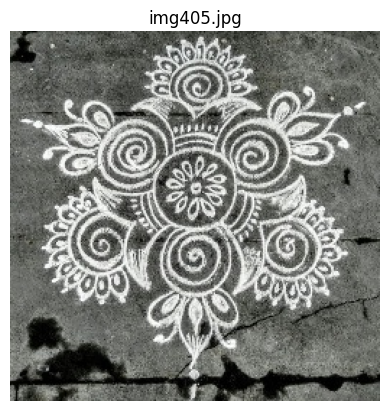


Predictions:

ResNet50: doormat (16.74%)
VGG16: doormat (63.85%)
Inception: velvet (23.52%)
MobileNet: velvet (9.22%)




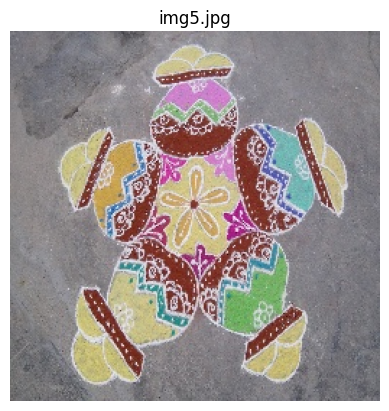


Predictions:

ResNet50: pillow (16.97%)
VGG16: bib (30.77%)
Inception: jersey (47.29%)
MobileNet: handkerchief (5.52%)




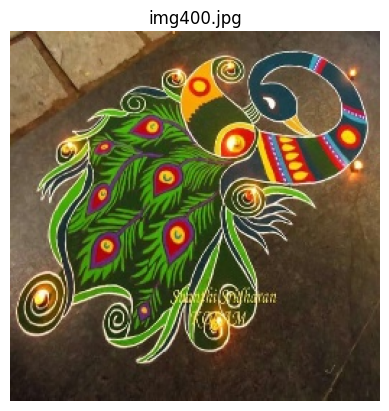


Predictions:

ResNet50: tray (59.55%)
VGG16: shield (28.25%)
Inception: purse (5.46%)
MobileNet: tray (4.76%)




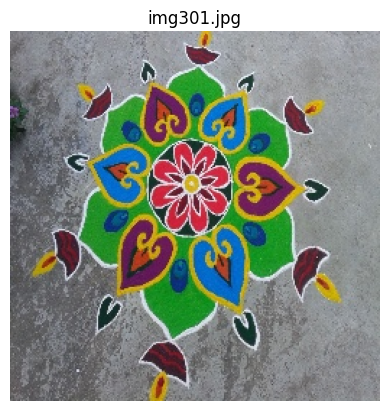


Predictions:

ResNet50: pillow (20.50%)
VGG16: handkerchief (21.93%)
Inception: shower curtain (13.69%)
MobileNet: pillow (8.78%)




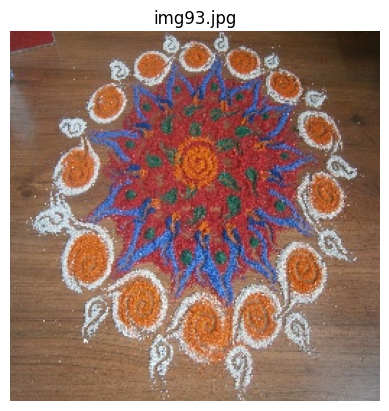


Predictions:

ResNet50: pillow (12.46%)
VGG16: prayer rug (62.93%)
Inception: prayer rug (40.72%)
MobileNet: prayer rug (4.79%)




In [62]:
import os
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import models, transforms
from PIL import Image
from torchvision.models import ResNet50_Weights


# =========================
# CONFIG
# =========================

DATASET_PATH = "/Users/jaeeponde/Thesis/Data_100/Rangoli"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

imagenet_labels = ResNet50_Weights.DEFAULT.meta["categories"]

transform_224 = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

transform_299 = transforms.Compose([
    transforms.Resize(342),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])


# =========================
# LOAD MODELS
# =========================

def load_models():

    resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

    inception = models.inception_v3(
        weights=models.Inception_V3_Weights.DEFAULT,
        aux_logits=True
    )
    inception.AuxLogits = None

    mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

    models_dict = {
        "ResNet50": (resnet, transform_224),
        "VGG16": (vgg, transform_224),
        "Inception": (inception, transform_299),
        "MobileNet": (mobilenet, transform_224)
    }

    for model, _ in models_dict.values():
        model.to(DEVICE)
        model.eval()

    return models_dict


# =========================
# MAIN
# =========================

def show_predictions():

    models_dict = load_models()

    files = [
        f for f in os.listdir(DATASET_PATH)
        if f.lower().endswith((".jpg",".png",".jpeg"))
    ]

    selected = random.sample(files, 5)

    for fname in selected:

        path = os.path.join(DATASET_PATH, fname)
        img = Image.open(path).convert("RGB")

        # 🔥 SHOW IMAGE
        plt.imshow(img)
        plt.title(fname)
        plt.axis("off")
        plt.show()

        print(f"\nPredictions:\n")

        for model_name, (model, transform) in models_dict.items():

            x = transform(img).unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                logits = model(x)

                if isinstance(logits, tuple):
                    logits = logits[0]

                probs = F.softmax(logits, dim=1)

                top1_val, top1_idx = torch.max(probs, dim=1)

            label = imagenet_labels[top1_idx.item()]
            conf = top1_val.item() * 100

            print(f"{model_name}: {label} ({conf:.2f}%)")

        print("\n" + "="*60 + "\n")


if __name__ == "__main__":
    show_predictions()